
In Telecom industry, the customers can choose from multiple service providers and switch between them. The industry experiences an average annual churn rate of 15-25%. Acquiring new customers is 5-10 times more expensive than retaining existing ones. Retaining highly profitable customers is crucial.

**Objective** is to predict whether a high-value customers will churn or not, in the churn phase.

Authors: Writika Bhaskar, Vivekanand

## Importing the libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

# To use functions from these modules later in the code

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA #Improting the PCA module
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

# Importing decision tree classifier from sklearn library
from sklearn.tree import DecisionTreeClassifier

# Importing random forest classifier from sklearn library
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from imblearn.over_sampling import SMOTE
from statsmodels.stats.outliers_influence import variance_inflation_factor # for VIF

import warnings
warnings.filterwarnings('ignore')  # to suppress any warnings 

# To display all the columns
pd.set_option('display.max_columns', 250)
pd.set_option('display.max_rows', 250)

## Understanding the data

A snapshot of what the rows and columns have

In [2]:
telecom = pd.read_csv('telecom_churn_data.csv')
telecom.head() # reading the dataframe

,mobile_number,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,last_date_of_month_9,arpu_6,arpu_7,arpu_8,arpu_9,onnet_mou_6,onnet_mou_7,onnet_mou_8,onnet_mou_9,offnet_mou_6,offnet_mou_7,offnet_mou_8,offnet_mou_9,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_ic_mou_9,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,roam_og_mou_9,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2t_mou_9,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2m_mou_9,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2f_mou_9,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_t2c_mou_9,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,loc_og_mou_9,std_og_t2t_mou_6,std_og_t2t_mou_7,std_og_t2t_mou_8,std_og_t2t_mou_9,std_og_t2m_mou_6,std_og_t2m_mou_7,std_og_t2m_mou_8,std_og_t2m_mou_9,std_og_t2f_mou_6,std_og_t2f_mou_7,std_og_t2f_mou_8,std_og_t2f_mou_9,std_og_t2c_mou_6,std_og_t2c_mou_7,std_og_t2c_mou_8,std_og_t2c_mou_9,std_og_mou_6,std_og_mou_7,std_og_mou_8,std_og_mou_9,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,isd_og_mou_9,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,spl_og_mou_9,og_others_6,og_others_7,og_others_8,og_others_9,total_og_mou_6,total_og_mou_7,total_og_mou_8,total_og_mou_9,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2t_mou_9,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2m_mou_9,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_t2f_mou_9,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,loc_ic_mou_9,std_ic_t2t_mou_6,std_ic_t2t_mou_7,std_ic_t2t_mou_8,std_ic_t2t_mou_9,std_ic_t2m_mou_6,std_ic_t2m_mou_7,std_ic_t2m_mou_8,std_ic_t2m_mou_9,std_ic_t2f_mou_6,std_ic_t2f_mou_7,std_ic_t2f_mou_8,std_ic_t2f_mou_9,std_ic_t2o_mou_6,std_ic_t2o_mou_7,std_ic_t2o_mou_8,std_ic_t2o_mou_9,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,std_ic_mou_9,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,total_ic_mou_9,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,spl_ic_mou_9,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,isd_ic_mou_9,ic_others_6,ic_others_7,ic_others_8,ic_others_9,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_num_9,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,total_rech_amt_9,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,max_rech_amt_9,date_of_last_rech_6,date_of_last_rech_7,date_of_last_rech_8,date_of_last_rech_9,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,last_day_rch_amt_9,date_of_last_rech_data_6,date_of_last_rech_data_7,date_of_last_rech_data_8,date_of_last_rech_data_9,total_rech_data_6,total_rech_data_7,total_rech_data_8,total_rech_data_9,max_rech_data_6,max_rech_data_7,max_rech_data_8,max_rech_data_9,count_rech_2g_6,count_rech_2g_7,count_rech_2g_8,count_rech_2g_9,count_rech_3g_6,count_rech_3g_7,count_rech_3g_8,count_rech_3g_9,av_rech_amt_data_6,av_rech_amt_data_7,av_rech_amt_data_8,av_rech_amt_data_9,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_2g_mb_9,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,vol_3g_mb_9,arpu_3g_6,arpu_3g_7,arpu_3g_8,arpu_3g_9,arpu_2g_6,arpu_2g_7,arpu_2g_8,arpu_2g_9,night_pck_user_6,night_pck_user_7,night_pck_user_8,night_pck_user_9,monthly_2g_6,monthly_2g_7,monthly_2g_8,monthly_2g_9,sachet_2g_6,sachet_2g_7,sachet_2g_8,sachet_2g_9,monthly_3g_6,monthly_3g_7,monthly_3g_8,monthly_3g_9,sachet_3g_6,sachet_3g_7,sachet_3g_8,sachet_3g_9,fb_user_6,fb_user_7,fb_user_8,fb_user_9,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,sep_vbc_3g
0,7000842753,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,197.385,214.816,213.803,21.100,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.0,NaN,0.00,0.00,0.00,0.00,NaN,NaN,0.16,NaN,NaN,NaN,4.13,NaN,NaN,NaN,1.15,NaN,NaN,NaN,5.44,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.00,NaN,0.00,0.00,5.44,0.00,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,4,3,

In [3]:
telecom.describe()

,mobile_number,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,arpu_6,arpu_7,arpu_8,arpu_9,onnet_mou_6,onnet_mou_7,onnet_mou_8,onnet_mou_9,offnet_mou_6,offnet_mou_7,offnet_mou_8,offnet_mou_9,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_ic_mou_9,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,roam_og_mou_9,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2t_mou_9,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2m_mou_9,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2f_mou_9,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_t2c_mou_9,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,loc_og_mou_9,std_og_t2t_mou_6,std_og_t2t_mou_7,std_og_t2t_mou_8,std_og_t2t_mou_9,std_og_t2m_mou_6,std_og_t2m_mou_7,std_og_t2m_mou_8,std_og_t2m_mou_9,std_og_t2f_mou_6,std_og_t2f_mou_7,std_og_t2f_mou_8,std_og_t2f_mou_9,std_og_t2c_mou_6,std_og_t2c_mou_7,std_og_t2c_mou_8,std_og_t2c_mou_9,std_og_mou_6,std_og_mou_7,std_og_mou_8,std_og_mou_9,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,isd_og_mou_9,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,spl_og_mou_9,og_others_6,og_others_7,og_others_8,og_others_9,total_og_mou_6,total_og_mou_7,total_og_mou_8,total_og_mou_9,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2t_mou_9,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2m_mou_9,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_t2f_mou_9,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,loc_ic_mou_9,std_ic_t2t_mou_6,std_ic_t2t_mou_7,std_ic_t2t_mou_8,std_ic_t2t_mou_9,std_ic_t2m_mou_6,std_ic_t2m_mou_7,std_ic_t2m_mou_8,std_ic_t2m_mou_9,std_ic_t2f_mou_6,std_ic_t2f_mou_7,std_ic_t2f_mou_8,std_ic_t2f_mou_9,std_ic_t2o_mou_6,std_ic_t2o_mou_7,std_ic_t2o_mou_8,std_ic_t2o_mou_9,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,std_ic_mou_9,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,total_ic_mou_9,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,spl_ic_mou_9,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,isd_ic_mou_9,ic_others_6,ic_others_7,ic_others_8,ic_others_9,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_num_9,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,total_rech_amt_9,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,max_rech_amt_9,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,last_day_rch_amt_9,total_rech_data_6,total_rech_data_7,total_rech_data_8,total_rech_data_9,max_rech_data_6,max_rech_data_7,max_rech_data_8,max_rech_data_9,count_rech_2g_6,count_rech_2g_7,count_rech_2g_8,count_rech_2g_9,count_rech_3g_6,count_rech_3g_7,count_rech_3g_8,count_rech_3g_9,av_rech_amt_data_6,av_rech_amt_data_7,av_rech_amt_data_8,av_rech_amt_data_9,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_2g_mb_9,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,vol_3g_mb_9,arpu_3g_6,arpu_3g_7,arpu_3g_8,arpu_3g_9,arpu_2g_6,arpu_2g_7,arpu_2g_8,arpu_2g_9,night_pck_user_6,night_pck_user_7,night_pck_user_8,night_pck_user_9,monthly_2g_6,monthly_2g_7,monthly_2g_8,monthly_2g_9,sachet_2g_6,sachet_2g_7,sachet_2g_8,sachet_2g_9,monthly_3g_6,monthly_3g_7,monthly_3g_8,monthly_3g_9,sachet_3g_6,sachet_3g_7,sachet_3g_8,sachet_3g_9,fb_user_6,fb_user_7,fb_user_8,fb_user_9,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,sep_vbc_3g
count,9.999900e+04,99999.0,98981.0,98981.0,98981.0,99999.000000,99999.000000,99999.000000,99999.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.0,96140.0,94621.0,92254.0,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621.000000,92254.000000,96062.000000,96140.000000,94621

In [4]:
telecom.shape

(99999, 226)

## Data Preparation

We are working over a four-month window, the first two months are the ‘good’ phase, the third month is the ‘action’ phase, while the fourth month is the ‘churn’ phase, which means

- The ‘good’ phase is month 6 & 7 (June, July)
- The ‘action’ phase is mnonth 8 (August)
- The ‘churn’ phase is month 9 (September)

The prepaid customers recharge with a certain amount in advance and then use the services. 

A high-value customers are who recharged with an amount more than or equal to 70th percentile of the recharge amount in the good months (6 and 7).

After identifying the high-value customers, we will tag churn  customers based on those who have not made any calls, used intereted even once in the churn phase. 


#### Finding avg recharge amount

We will first calculate total recharge amount and total recharge data and then calculating the average recharge amount



In [5]:
rech_cols = ['total_rech_data_6','total_rech_data_7','total_rech_data_8','av_rech_amt_data_6','av_rech_amt_data_7','av_rech_amt_data_8']

In [6]:
# Calculate the percentage of missing values in each column
telecom_missing_check = 100 * telecom.loc[:,rech_cols].isnull().mean()

# create a dataframe with the column name 'Null_Percentage'
df = pd.DataFrame(telecom_missing_check, columns=['Missing_Percentage'])
df

,Missing_Percentage
total_rech_data_6,74.846748
total_rech_data_7,74.428744
total_rech_data_8,73.660737
av_rech_amt_data_6,74.846748
av_rech_amt_data_7,74.428744
av_rech_amt_data_8,73.660737


**Interpretation**
All related columns have ~74% missing values. 

We can impute in the missing values (NA) with a constant value of 0. This is based on the assumption that 1 is the lowest possible amount of recharge done by the customer, therefore any missing value can be interpreted as no recharge at all which means 0

In [7]:
def replace_nan(df, col_list, value):
    # loop through the columns in the list
    for col in col_list:
        # replace NaN with value
        df[col] = df[col].replace(np.NaN, value)


In [8]:
#Imputing NaN with 0 since NaN may mean no recharge at all
replace_nan(telecom, rech_cols, 0.0)

In [9]:
# Checking if missing values are imputed in each column
telecom_missing_check = 100 * telecom.loc[:,rech_cols].isnull().mean()
df = pd.DataFrame(telecom_missing_check, columns=['Missing_Percentage'])
df

,Missing_Percentage
total_rech_data_6,0.0
total_rech_data_7,0.0
total_rech_data_8,0.0
av_rech_amt_data_6,0.0
av_rech_amt_data_7,0.0
av_rech_amt_data_8,0.0


By multiplying the total number of recharges for data (total_rech_data) and the average recharge amount for data (av_rech_amt_data), we can get the a new feature total recharge amount for data (**total_rech_amt_data**). This feature can indicate how much the customer is willing to spend on data services, and how frequently they use them. This helps us identify most likely to churn or stay loyal. 

In [10]:
# Adding new column total recharge amount for data: total_rech_amt_data for calculating High Value customer process
# loop over the months 6, 7, 8 and 9
for month in range(6, 10):
    # create the new column name
    new_col = f'total_rech_amt_data_{month}'
    # calculate the new column value
    telecom[new_col] = telecom[f'av_rech_amt_data_{month}'] * telecom[f'total_rech_data_{month}']


In [11]:
# Check the information of total recharge amount columns
telecom[['total_rech_amt_6','total_rech_amt_7','total_rech_amt_8']].describe(percentiles=[.25,.5,.75,.90,.95,.99,1])


,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8
count,99999.000000,99999.000000,99999.000000
mean,327.514615,322.962970,324.157122
std,398.019701,408.114237,416.540455
min,0.000000,0.000000,0.000000
25%,109.000000,100.000000,90.000000
50%,230.000000,220.000000,225.000000
75%,437.500000,428.000000,434.500000
90%,732.000000,731.000000,736.000000
95%,994.000000,993.000000,996.000000
99%,1683.020000,1728.000000,1721.000000


There are no null values in total_rech_amt columns of all 3 months.

In [12]:
#Function to identify categorical or continuous columns
def col_analysis(dataframe):
    numerical_df = dataframe.select_dtypes(include='number')
    categorical_df = dataframe.select_dtypes(exclude='number')
    print('Total numerical columns : {}'.format(numerical_df.shape[1]))
    print('Total categorical columns : {}'.format(categorical_df.shape[1]))
    return numerical_df, categorical_df

In [13]:
telecom_numerical_col, telecom_categorical_col = col_analysis(telecom)


Total numerical columns : 218
Total categorical columns : 12


#### Deriving new features

- total recharge amount 
- total  amount from data recharge and ic/og calls
- average amount for the good and action phase


In [14]:
# loop over the months 6, 7, and 8
for month in range(6, 9):
    # calculate the total data recharge amount for each month
    telecom['total_data_rech_amt_' + str(month)] = telecom['total_rech_data_' + str(month)] * telecom['av_rech_amt_data_' + str(month)]
    # calculate the total amount from data recharge and ic/og calls for each month
    telecom['call_data_amt_' + str(month)] = telecom[['total_rech_amt_' + str(month), 'total_data_rech_amt_' + str(month)]].sum(axis=1)

# calculate the average of amount for the first 2 months
telecom['good_phase_amt_avg'] = telecom[['call_data_amt_6', 'call_data_amt_7']].mean(axis=1)
# calculate the average of amount for the action month
telecom['action_phase_amt_avg'] = telecom['call_data_amt_8']


In [15]:
#checking the new features
telecom[['good_phase_amt_avg', 'total_rech_amt_6', 'total_rech_amt_7', 'total_data_rech_amt_6', 'total_data_rech_amt_7']].head()


,good_phase_amt_avg,total_rech_amt_6,total_rech_amt_7,total_data_rech_amt_6,total_data_rech_amt_7
0,559.0,362,252,252.0,252.0
1,306.0,74,384,0.0,154.0
2,241.5,168,315,0.0,0.0
3,270.0,230,310,0.0,0.0
4,301.0,196,350,56.0,0.0


#### Finding high value customers

In [16]:
# Filter the records of high value customers whose recharge amount should be more than 70th percentile
telecom_hvc = telecom[telecom['good_phase_amt_avg'] >= telecom['good_phase_amt_avg'].quantile(0.7)]

# Print the number and information of high value customers
print("Number of high value customers: ", len(telecom_hvc))

print("Average recharge amount of high value customers in good phase: ", telecom['good_phase_amt_avg'].quantile(0.7))



Number of high value customers:  30001
Average recharge amount of high value customers in good phase:  478.0


**Interpretation**
~30K as high value customers recharged 478.0 in  the good phase

#### Tag churned customers

We will assign churn = 1 to the customers who have not made any either incoming or outgoing calls AND also have not used data not once in the churn phase. The columns we will tag churners are:

- total_ic_mou_9
- total_og_mou_9
- vol_2g_mb_9
- vol_3g_mb_9

In [17]:
# create the churn column using the assign method
telecom_hvc = telecom_hvc.assign(churn = lambda x: np.where(
                            ((x['total_ic_mou_9'] == 0.00) | (x['total_og_mou_9'] == 0.00))
                            & ((x['vol_2g_mb_9'] == 0.00) | (x['vol_3g_mb_9'] == 0.00))
                            , 1, 0
                           ))

# print the count of churned and non-churned customers
print(telecom_hvc['churn'].value_counts())

# print the proportion of churned and non-churned customers using the mean method
print(telecom_hvc['churn'].value_counts()/telecom_hvc.shape[0])


0    26735
1     3266
Name: churn, dtype: int64
0    0.891137
1    0.108863
Name: churn, dtype: float64


In [18]:
telecom_hvc[['churn','total_ic_mou_9','total_og_mou_9','vol_2g_mb_9','vol_3g_mb_9']].head(10)


,churn,total_ic_mou_9,total_og_mou_9,vol_2g_mb_9,vol_3g_mb_9
0,1,0.00,0.00,0.00,0.00
7,1,0.00,0.00,0.00,0.00
8,0,34.91,142.18,0.00,0.00
21,0,252.61,1031.53,0.00,0.00
23,0,127.48,127.63,13.93,314.74
33,0,114.16,1.70,30.92,5588.11
38,0,114.09,708.04,0.00,0.00
41,0,165.84,89.13,0.00,0.00
48,0,894.81,2319.01,0.00,0.00
53,0,680.61,503.06,0.82,0.00


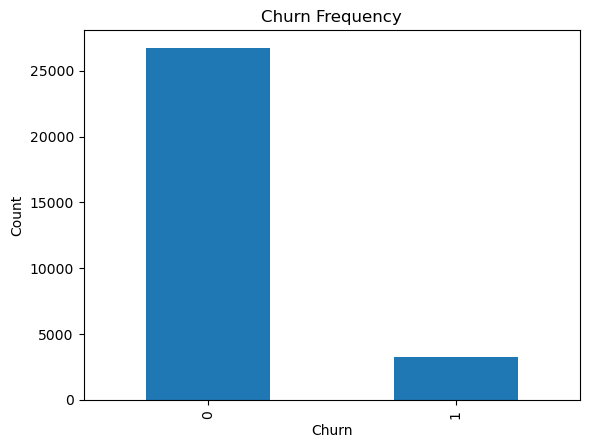

In [19]:
# Check the unique values count in churn column
telecom_hvc.churn.value_counts()
telecom_hvc['churn'].value_counts().plot(kind='bar')
plt.title('Churn Frequency')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

## Data understanding, preparation, and feature engineering



In [20]:
# Creating a reusable function to drop one or more columns

def drop_cols(df, col_list):
    try:
        df.drop(columns=col_list, inplace=True)
        print(f"Dropped columns: {', '.join(col_list)}")
    except KeyError:
        print("One or more columns not found in the DataFrame.")

Since we have taggeld the churned customers, we will be dropping all attributes having ‘ _9’ or sep in their names.

In [21]:
#Identifying the columns to drop of the 9th month
cols_to_drop = telecom_hvc.columns[telecom_hvc.columns.str.endswith(pat='9')]|telecom_hvc.columns[telecom_hvc.columns.str.contains('sep')]
print(cols_to_drop)
print(len(cols_to_drop))

Index(['arpu_2g_9', 'arpu_3g_9', 'arpu_9', 'av_rech_amt_data_9',
       'count_rech_2g_9', 'count_rech_3g_9', 'date_of_last_rech_9',
       'date_of_last_rech_data_9', 'fb_user_9', 'ic_others_9', 'isd_ic_mou_9',
       'isd_og_mou_9', 'last_date_of_month_9', 'last_day_rch_amt_9',
       'loc_ic_mou_9', 'loc_ic_t2f_mou_9', 'loc_ic_t2m_mou_9',
       'loc_ic_t2t_mou_9', 'loc_og_mou_9', 'loc_og_t2c_mou_9',
       'loc_og_t2f_mou_9', 'loc_og_t2m_mou_9', 'loc_og_t2t_mou_9',
       'max_rech_amt_9', 'max_rech_data_9', 'monthly_2g_9', 'monthly_3g_9',
       'night_pck_user_9', 'offnet_mou_9', 'og_others_9', 'onnet_mou_9',
       'roam_ic_mou_9', 'roam_og_mou_9', 'sachet_2g_9', 'sachet_3g_9',
       'sep_vbc_3g', 'spl_ic_mou_9', 'spl_og_mou_9', 'std_ic_mou_9',
       'std_ic_t2f_mou_9', 'std_ic_t2m_mou_9', 'std_ic_t2o_mou_9',
       'std_ic_t2t_mou_9', 'std_og_mou_9', 'std_og_t2c_mou_9',
       'std_og_t2f_mou_9', 'std_og_t2m_mou_9', 'std_og_t2t_mou_9',
       'total_ic_mou_9', 'total_og_mou_9

In [22]:
drop_cols(telecom_hvc, cols_to_drop)
telecom_hvc.head()

Dropped columns: arpu_2g_9, arpu_3g_9, arpu_9, av_rech_amt_data_9, count_rech_2g_9, count_rech_3g_9, date_of_last_rech_9, date_of_last_rech_data_9, fb_user_9, ic_others_9, isd_ic_mou_9, isd_og_mou_9, last_date_of_month_9, last_day_rch_amt_9, loc_ic_mou_9, loc_ic_t2f_mou_9, loc_ic_t2m_mou_9, loc_ic_t2t_mou_9, loc_og_mou_9, loc_og_t2c_mou_9, loc_og_t2f_mou_9, loc_og_t2m_mou_9, loc_og_t2t_mou_9, max_rech_amt_9, max_rech_data_9, monthly_2g_9, monthly_3g_9, night_pck_user_9, offnet_mou_9, og_others_9, onnet_mou_9, roam_ic_mou_9, roam_og_mou_9, sachet_2g_9, sachet_3g_9, sep_vbc_3g, spl_ic_mou_9, spl_og_mou_9, std_ic_mou_9, std_ic_t2f_mou_9, std_ic_t2m_mou_9, std_ic_t2o_mou_9, std_ic_t2t_mou_9, std_og_mou_9, std_og_t2c_mou_9, std_og_t2f_mou_9, std_og_t2m_mou_9, std_og_t2t_mou_9, total_ic_mou_9, total_og_mou_9, total_rech_amt_9, total_rech_amt_data_9, total_rech_data_9, total_rech_num_9, vol_2g_mb_9, vol_3g_mb_9


,mobile_number,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,std_og_t2t_mou_6,std_og_t2t_mou_7,std_og_t2t_mou_8,std_og_t2m_mou_6,std_og_t2m_mou_7,std_og_t2m_mou_8,std_og_t2f_mou_6,std_og_t2f_mou_7,std_og_t2f_mou_8,std_og_t2c_mou_6,std_og_t2c_mou_7,std_og_t2c_mou_8,std_og_mou_6,std_og_mou_7,std_og_mou_8,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,og_others_6,og_others_7,og_others_8,total_og_mou_6,total_og_mou_7,total_og_mou_8,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,std_ic_t2t_mou_6,std_ic_t2t_mou_7,std_ic_t2t_mou_8,std_ic_t2m_mou_6,std_ic_t2m_mou_7,std_ic_t2m_mou_8,std_ic_t2f_mou_6,std_ic_t2f_mou_7,std_ic_t2f_mou_8,std_ic_t2o_mou_6,std_ic_t2o_mou_7,std_ic_t2o_mou_8,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,ic_others_6,ic_others_7,ic_others_8,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,date_of_last_rech_6,date_of_last_rech_7,date_of_last_rech_8,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,date_of_last_rech_data_6,date_of_last_rech_data_7,date_of_last_rech_data_8,total_rech_data_6,total_rech_data_7,total_rech_data_8,max_rech_data_6,max_rech_data_7,max_rech_data_8,count_rech_2g_6,count_rech_2g_7,count_rech_2g_8,count_rech_3g_6,count_rech_3g_7,count_rech_3g_8,av_rech_amt_data_6,av_rech_amt_data_7,av_rech_amt_data_8,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,arpu_3g_6,arpu_3g_7,arpu_3g_8,arpu_2g_6,arpu_2g_7,arpu_2g_8,night_pck_user_6,night_pck_user_7,night_pck_user_8,monthly_2g_6,monthly_2g_7,monthly_2g_8,sachet_2g_6,sachet_2g_7,sachet_2g_8,monthly_3g_6,monthly_3g_7,monthly_3g_8,sachet_3g_6,sachet_3g_7,sachet_3g_8,fb_user_6,fb_user_7,fb_user_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,total_rech_amt_data_6,total_rech_amt_data_7,total_rech_amt_data_8,total_data_rech_amt_6,call_data_amt_6,total_data_rech_amt_7,call_data_amt_7,total_data_rech_amt_8,call_data_amt_8,good_phase_amt_avg,action_phase_amt_avg,churn
0,7000842753,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,197.385,214.816,213.803,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,0.0,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,0.0,0.00,0.00,0.00,NaN,NaN,0.16,NaN,NaN,4.13,NaN,NaN,1.15,NaN,NaN,5.44,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,0.0,NaN,NaN,0.00,0.00,0.00,5.44,NaN,NaN,0.0,NaN,NaN,0.00,NaN,NaN,0.00,4,3,2,362,252,252,252,252,252,6/21/2014,7/16/2014,8/8/2014,252,252,252,6/21/2014,7/16/2014,8/8/2014,1.0,1.0,1.0,252.0,252.0,252.0,0.0,0.0,0.0,1.0,1.0,1.0,252.0,252.0,252.0,30.13,1.32,5.75,83.57,150.76,109.61,212.17,212.17,212.17,212.17,212.17,212.17,0.0,0.0,0.0,0,0,0,0,0,0,1,1,1,0,0,0,1.0,1.0,1.0,968,30.40,0.00,101.20,252.0,252.0,252.0,252.0,614.0,252.0,504.0,252.0,504.0,559.0,504.0,1
7,7000701601,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,1069.180,1349.850,3171.480,57.84,54.68,52.29,453.43,567.16,325.91,16.23,33.49,31.64,23.74,12.59,38.06,51.39,31.38,40.28,308.63,447.38,162.28,62.13,55.14,53.23,0.0,0.0,0.00,422.16,533.91,255.79,4.30,23.29,12.01,49.89,31.76,49.14,6.66,20.08,16.68,0.0,0.0,0.0,60.86,75.14,77.84,0.0,0.18,10.01,4.5,0

In [23]:
# Shape of the dataframe of high value customers
telecom_hvc.shape

(30001, 183)

#### Treating columns with unique values less than 2
We will be calculating the unique values and then dropping the columns that have less than 2 unique values is to reduce the dimensionality of the data and remove the redundant features.

In [24]:
# function to Calculate percentage
def calculate_percentage(value, base, round_digits = 2):
    return round((value/base)*100, round_digits)

# Check Missing value percentage for each columns
pd.options.display.float_format = '{:.2f}'.format
missing_values = pd.DataFrame((telecom_hvc.isnull().sum()/len(telecom_hvc))*100).reset_index().rename(columns = {'index': 'feature', 0: 'Missing%'}).sort_values('Missing%',ascending = False)
missing_values

# Delete all such columns having unique values less than 2
# Get the number of unique values in each column, excluding missing values
unique_values = telecom_hvc.nunique(dropna=True)
# Get the columns that have less than 2 unique values
cols_to_drop = unique_values[unique_values < 2].index
# Drop these columns using the df.drop method
telecom_hvc.drop(cols_to_drop, axis=1, inplace=True)

# Printing the dataframe shape
print(f"In telecom_hvc, there are {telecom_hvc.shape[0]} rows and {telecom_hvc.shape[1]} columns now")


In telecom_hvc, there are 30001 rows and 170 columns now


In [25]:
#calling the function we made earlier to redo the column analysis
telecom_numerical_col, telecom_categorical_col = col_analysis(telecom_hvc)

Total numerical columns : 164
Total categorical columns : 6


#### Treating columns with missing values more than 70%
We drop such columns as there is not enough information in these columns to be useful for prediction

In [26]:
null_percentage = 0.70
na_perc_rows = round(telecom_hvc.isnull().sum(axis=1) / len(telecom_hvc.columns),2 )
print("\nNumber of rows which has more than 70% null values before dropping = ", na_perc_rows[na_perc_rows > null_percentage].count())

thres = np.int(len(telecom_hvc.columns)*round(1-null_percentage, 1))
print("Threshold value before dropping = ", thres)

print("Total Number of rows before dropping = ", len(telecom_hvc))
telecom_hvc.dropna(thresh=thres,inplace=True)

na_perc_rows = round(telecom_hvc.isnull().sum(axis=1) / len(telecom_hvc.columns),2 )
print("\nNumber of rows which has more than 70% null values after droppping = ", na_perc_rows[na_perc_rows > null_percentage].count())
print("Total Number of rows after dropping = ", len(telecom_hvc))


Number of rows which has more than 70% null values before dropping =  0
Threshold value before dropping =  51
Total Number of rows before dropping =  30001

Number of rows which has more than 70% null values after droppping =  0
Total Number of rows after dropping =  30001


In [27]:
telecom_hvc.shape

(30001, 170)

#### Treating columns with null values
Identify how many missing values (NaN) are present in each column of your DataFrame

In [28]:
#Let us first calculate the percentage of missing values in each column
na_percent = round(telecom_hvc.isnull().sum() / len(telecom_hvc.index) * 100, 2)

# Filter and printthe columns that have at least one missing value
na_percent = na_percent[na_percent > 0]
print(f"Number of columns which has at least one null value is {na_percent.count()}")

# Sort the columns by the percentage of missing values in descending order
na_percent.sort_values(ascending=False)


Number of columns which has at least one null value is 108


fb_user_8                  46.83
arpu_2g_8                  46.83
date_of_last_rech_data_8   46.83
max_rech_data_8            46.83
count_rech_2g_8            46.83
arpu_3g_8                  46.83
count_rech_3g_8            46.83
night_pck_user_8           46.83
count_rech_3g_6            44.15
night_pck_user_6           44.15
date_of_last_rech_data_6   44.15
arpu_2g_6                  44.15
max_rech_data_6            44.15
count_rech_2g_6            44.15
arpu_3g_6                  44.15
fb_user_6                  44.15
count_rech_3g_7            43.15
date_of_last_rech_data_7   43.15
max_rech_data_7            43.15
fb_user_7                  43.15
count_rech_2g_7            43.15
night_pck_user_7           43.15
arpu_3g_7                  43.15
arpu_2g_7                  43.15
std_ic_t2m_mou_8            3.91
og_others_8                 3.91
std_ic_mou_8                3.91
std_og_mou_8                3.91
spl_ic_mou_8                3.91
loc_ic_t2t_mou_8            3.91
spl_og_mou

##### Treating columns related to mou (Minutes of usage)
By definition 

ONNET = Calls made within the same operator network
OFFNET = Calls outside the operator T network
IC = Incoming calls
ROAM = Calls made during roaming
OG = Outgoing calls
LOC = Local calls - calls made within same telecom circle
STD = STD calls - calls made the calling circle
T2T = Operator T to T, i.e. calls made within same operator (mobile to mobile)
T2M = Operator T to other operator mobile
T2F = Operator T to fixed lines of T
T2C = Operator T to it’s own call center
T2O = Operator T to other operator fixed line

Therefore if the minutes of usage for any calls is missing, we can safely assum that there was no call made and hence can be imputed with 0.


In [29]:
# Select and print the columns that have '_mou' in their names
mou_cols = telecom_hvc.columns[telecom_hvc.columns.str.contains(pat = 'mou')]
print("MOU columns\n", mou_cols.values)

MOU columns
 ['onnet_mou_6' 'onnet_mou_7' 'onnet_mou_8' 'offnet_mou_6' 'offnet_mou_7'
 'offnet_mou_8' 'roam_ic_mou_6' 'roam_ic_mou_7' 'roam_ic_mou_8'
 'roam_og_mou_6' 'roam_og_mou_7' 'roam_og_mou_8' 'loc_og_t2t_mou_6'
 'loc_og_t2t_mou_7' 'loc_og_t2t_mou_8' 'loc_og_t2m_mou_6'
 'loc_og_t2m_mou_7' 'loc_og_t2m_mou_8' 'loc_og_t2f_mou_6'
 'loc_og_t2f_mou_7' 'loc_og_t2f_mou_8' 'loc_og_t2c_mou_6'
 'loc_og_t2c_mou_7' 'loc_og_t2c_mou_8' 'loc_og_mou_6' 'loc_og_mou_7'
 'loc_og_mou_8' 'std_og_t2t_mou_6' 'std_og_t2t_mou_7' 'std_og_t2t_mou_8'
 'std_og_t2m_mou_6' 'std_og_t2m_mou_7' 'std_og_t2m_mou_8'
 'std_og_t2f_mou_6' 'std_og_t2f_mou_7' 'std_og_t2f_mou_8' 'std_og_mou_6'
 'std_og_mou_7' 'std_og_mou_8' 'isd_og_mou_6' 'isd_og_mou_7'
 'isd_og_mou_8' 'spl_og_mou_6' 'spl_og_mou_7' 'spl_og_mou_8'
 'total_og_mou_6' 'total_og_mou_7' 'total_og_mou_8' 'loc_ic_t2t_mou_6'
 'loc_ic_t2t_mou_7' 'loc_ic_t2t_mou_8' 'loc_ic_t2m_mou_6'
 'loc_ic_t2m_mou_7' 'loc_ic_t2m_mou_8' 'loc_ic_t2f_mou_6'
 'loc_ic_t2f_mou_7' 'loc_i

In [30]:
# Drop the columns that have less than 2 unique values from the df_hvc DataFrame
unique_values = telecom_hvc.nunique(dropna=True)
cols_to_drop = unique_values[unique_values < 2].index
telecom_hvc.drop(cols_to_drop, axis=1, inplace=True)

# Recalculate the percentage of missing values in each column
na_percent = telecom_hvc.isna().mean(axis=0) * 100

# Print the percentage of missing values of these columns
print(na_percent[mou_cols.values].unique())

[1.81660611 1.78994034 3.91320289 0.        ]


In [31]:
# Print the first two rows of these columns
telecom_hvc[mou_cols].head()

,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,std_og_t2t_mou_6,std_og_t2t_mou_7,std_og_t2t_mou_8,std_og_t2m_mou_6,std_og_t2m_mou_7,std_og_t2m_mou_8,std_og_t2f_mou_6,std_og_t2f_mou_7,std_og_t2f_mou_8,std_og_mou_6,std_og_mou_7,std_og_mou_8,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,total_og_mou_6,total_og_mou_7,total_og_mou_8,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,std_ic_t2t_mou_6,std_ic_t2t_mou_7,std_ic_t2t_mou_8,std_ic_t2m_mou_6,std_ic_t2m_mou_7,std_ic_t2m_mou_8,std_ic_t2f_mou_6,std_ic_t2f_mou_7,std_ic_t2f_mou_8,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8
0,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,0.00,0.00,0.00,0.00,NaN,NaN,0.16,NaN,NaN,4.13,NaN,NaN,1.15,NaN,NaN,5.44,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,0.00,NaN,NaN,0.00,0.00,0.00,5.44,NaN,NaN,0.00,NaN,NaN,0.00
7,57.84,54.68,52.29,453.43,567.16,325.91,16.23,33.49,31.64,23.74,12.59,38.06,51.39,31.38,40.28,308.63,447.38,162.28,62.13,55.14,53.23,0.00,0.00,0.00,422.16,533.91,255.79,4.30,23.29,12.01,49.89,31.76,49.14,6.66,20.08,16.68,60.86,75.14,77.84,0.00,0.18,10.01,4.50,0.00,6.50,487.53,609.24,350.16,58.14,32.26,27.31,217.56,221.49,121.19,152.16,101.46,39.53,427.88,355.23,188.04,36.89,11.83,30.39,91.44,126.99,141.33,52.19,34.24,22.21,180.54,173.08,193.94,626.46,558.04,428.74,0.21,0.00,0.00,2.06,14.53,31.59
8,413.69,351.03,35.08,94.66,80.63,136.48,0.00,0.00,0.00,0.00,0.00,0.00,297.13,217.59,12.49,80.96,70.58,50.54,0.00,0.00,0.00,0.00,0.00,7.15,378.09,288.18,63.04,116.56,133.43,22.58,13.69,10.04,75.69,0.00,0.00,0.00,130.26,143.48,98.28,0.00,0.00,0.00,0.00,0.00,10.23,508.36,431.66,171.56,23.84,9.84,0.31,57.58,13.98,15.48,0.00,0.00,0.00,81.43,23.83,15.79,0.00,0.58,0.10,22.43,4.08,0.65,0.00,0.00,0.00,22.43,4.66,0.75,103.86,28.49,16.54,0.00,0.00,0.00,0.00,0.00,0.00
21,102.41,132.11,85.14,757.93,896.68,983.39,0.00,0.00,0.00,0.00,0.00,0.00,4.48,6.16,23.34,91.81,87.93,104.81,0.75,0.00,1.58,0.00,0.00,0.00,97.04,94.09,129.74,97.93,125.94,61.79,665.36,808.74,876.99,0.00,0.00,0.00,763.29,934.69,938.79,0.00,0.00,0.00,0.00,0.00,0.00,860.34,1028.79,1068.54,2.48,10.19,19.54,118.23,74.63,129.16,4.61,2.84,10.39,125.33,87.68,159.11,14.06,5.98,0.18,67.69,38.23,101.74,0.00,0.00,0.00,81.76,44.21,101.93,207.09,131.89,261.04,0.00,0.00,0.00,0.00,0.00,0.00
23,48.96,50.66,33.58,85.41,89.36,205.89,0.00,0.00,0.00,0.00,0.00,0.00,48.96,50.66,33.58,82.94,83.01,148.56,0.00,0.00,0.00,0.00,0.00,17.71,131.91,133.68,182.14,0.00,0.00,0.00,2.36,6.35,39.61,0.00,0.00,0.00,2.36,6.35,39.61,0.00,0.01,0.00,0.10,0.00,17.71,134.38,140.04,239.48,20.71,61.04,76.64,95.91,113.36,146.84,0.00,0.00,0.71,116.63,174.41,224.21,0.51,0.00,13.38,2.43,14.89,43.91,0.00,0.00,0.00,2.94,14.89,57.29,119.58,222.89,298.33,0.00,0.00,0.00,0.00,28.23,3.74


**Interpretation**
All mou related fields has a 4% of missing values which can be imputed by 0. 

In [32]:
#imputing mou related colulmsn with 04
telecom_hvc[mou_cols] = telecom_hvc[mou_cols].fillna(0)
telecom_hvc.head()

,mobile_number,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,std_og_t2t_mou_6,std_og_t2t_mou_7,std_og_t2t_mou_8,std_og_t2m_mou_6,std_og_t2m_mou_7,std_og_t2m_mou_8,std_og_t2f_mou_6,std_og_t2f_mou_7,std_og_t2f_mou_8,std_og_mou_6,std_og_mou_7,std_og_mou_8,isd_og_mou_6,isd_og_mou_7,isd_og_mou_8,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,og_others_6,og_others_7,og_others_8,total_og_mou_6,total_og_mou_7,total_og_mou_8,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,std_ic_t2t_mou_6,std_ic_t2t_mou_7,std_ic_t2t_mou_8,std_ic_t2m_mou_6,std_ic_t2m_mou_7,std_ic_t2m_mou_8,std_ic_t2f_mou_6,std_ic_t2f_mou_7,std_ic_t2f_mou_8,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,spl_ic_mou_6,spl_ic_mou_7,spl_ic_mou_8,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,ic_others_6,ic_others_7,ic_others_8,total_rech_num_6,total_rech_num_7,total_rech_num_8,total_rech_amt_6,total_rech_amt_7,total_rech_amt_8,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,date_of_last_rech_6,date_of_last_rech_7,date_of_last_rech_8,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,date_of_last_rech_data_6,date_of_last_rech_data_7,date_of_last_rech_data_8,total_rech_data_6,total_rech_data_7,total_rech_data_8,max_rech_data_6,max_rech_data_7,max_rech_data_8,count_rech_2g_6,count_rech_2g_7,count_rech_2g_8,count_rech_3g_6,count_rech_3g_7,count_rech_3g_8,av_rech_amt_data_6,av_rech_amt_data_7,av_rech_amt_data_8,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,arpu_3g_6,arpu_3g_7,arpu_3g_8,arpu_2g_6,arpu_2g_7,arpu_2g_8,night_pck_user_6,night_pck_user_7,night_pck_user_8,monthly_2g_6,monthly_2g_7,monthly_2g_8,sachet_2g_6,sachet_2g_7,sachet_2g_8,monthly_3g_6,monthly_3g_7,monthly_3g_8,sachet_3g_6,sachet_3g_7,sachet_3g_8,fb_user_6,fb_user_7,fb_user_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,total_rech_amt_data_6,total_rech_amt_data_7,total_rech_amt_data_8,total_data_rech_amt_6,call_data_amt_6,total_data_rech_amt_7,call_data_amt_7,total_data_rech_amt_8,call_data_amt_8,good_phase_amt_avg,action_phase_amt_avg,churn
0,7000842753,197.38,214.82,213.80,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.16,0.00,0.00,4.13,0.00,0.00,1.15,0.00,0.00,5.44,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5.44,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN,0.00,4,3,2,362,252,252,252,252,252,6/21/2014,7/16/2014,8/8/2014,252,252,252,6/21/2014,7/16/2014,8/8/2014,1.00,1.00,1.00,252.00,252.00,252.00,0.00,0.00,0.00,1.00,1.00,1.00,252.00,252.00,252.00,30.13,1.32,5.75,83.57,150.76,109.61,212.17,212.17,212.17,212.17,212.17,212.17,0.00,0.00,0.00,0,0,0,0,0,0,1,1,1,0,0,0,1.00,1.00,1.00,968,30.40,0.00,101.20,252.00,252.00,252.00,252.00,614.00,252.00,504.00,252.00,504.00,559.00,504.00,1
7,7000701601,1069.18,1349.85,3171.48,57.84,54.68,52.29,453.43,567.16,325.91,16.23,33.49,31.64,23.74,12.59,38.06,51.39,31.38,40.28,308.63,447.38,162.28,62.13,55.14,53.23,0.00,0.00,0.00,422.16,533.91,255.79,4.30,23.29,12.01,49.89,31.76,49.14,6.66,20.08,16.68,60.86,75.14,77.84,0.00,0.18,10.01,4.50,0.00,6.50,0.00,0.00,0.00,487.53,609.24,350.16,58.14,32.26,27.31,217.56,221.49,121.19,152.16,101.46,39.53,427.88,355.23,188.04,36.89,11.83,30.39,91.44,126.99,141.33,52.19,34.24,22.21,180.54,173.08,193.94,626.46,558.04,428.74,0.21,0.00,0.00,2.06,14.53,31.59,15.74,15.19

In [33]:
# checking if imputing was succsessful
print(telecom_hvc[mou_cols].isnull().sum().unique())


[0]


##### Treating columns last recharge columns


In [34]:
telecom_categorical_col.columns

Index(['date_of_last_rech_6', 'date_of_last_rech_7', 'date_of_last_rech_8',
       'date_of_last_rech_data_6', 'date_of_last_rech_data_7',
       'date_of_last_rech_data_8'],
      dtype='object')

**Interpretaion**
We can impute the null values with the end of the month is to assume that the customer did not recharge at all in that month, and thus the last recharge date is the same as the last date of the month. This way, we can avoid dropping the rows with missing values and retain more data for analysis. 

In [35]:
# Impute NaN values with end of month date by default
telecom_hvc.date_of_last_rech_6.fillna('6/30/2014', inplace=True)
telecom_hvc.date_of_last_rech_7.fillna('7/31/2014', inplace=True)
telecom_hvc.date_of_last_rech_8.fillna('8/31/2014', inplace=True)

telecom_hvc.date_of_last_rech_data_6.fillna('6/30/2014', inplace=True)
telecom_hvc.date_of_last_rech_data_7.fillna('7/31/2014', inplace=True)
telecom_hvc.date_of_last_rech_data_8.fillna('8/31/2014', inplace=True)

In [36]:
telecom_hvc['date_of_last_rech_6'] = pd.to_datetime(telecom_hvc['date_of_last_rech_6'])
telecom_hvc['date_of_last_rech_7'] = pd.to_datetime(telecom_hvc['date_of_last_rech_7'])
telecom_hvc['date_of_last_rech_8'] = pd.to_datetime(telecom_hvc['date_of_last_rech_8'])

telecom_hvc['date_of_last_rech_data_6'] = pd.to_datetime(telecom_hvc['date_of_last_rech_data_6'])
telecom_hvc['date_of_last_rech_data_7'] = pd.to_datetime(telecom_hvc['date_of_last_rech_data_7'])
telecom_hvc['date_of_last_rech_data_8'] = pd.to_datetime(telecom_hvc['date_of_last_rech_data_8'])

In [37]:
telecom_hvc['day_of_last_rech_6'] = telecom_hvc['date_of_last_rech_6'].dt.day
telecom_hvc['day_of_last_rech_7'] = telecom_hvc['date_of_last_rech_7'].dt.day
telecom_hvc['day_of_last_rech_8'] = telecom_hvc['date_of_last_rech_8'].dt.day

telecom_hvc['day_of_last_rech_data_6'] = telecom_hvc['date_of_last_rech_data_6'].dt.day
telecom_hvc['day_of_last_rech_data_7'] = telecom_hvc['date_of_last_rech_data_7'].dt.day
telecom_hvc['day_of_last_rech_data_8'] = telecom_hvc['date_of_last_rech_data_8'].dt.day

In [38]:
#Filling the missing value with as the customer did not recharge in a month, so the last recharge is set to 0

telecom_hvc[['day_of_last_rech_6','day_of_last_rech_7',
            'day_of_last_rech_8']] = telecom_hvc[['day_of_last_rech_6','day_of_last_rech_7',
                                                                      'day_of_last_rech_8']]\
.fillna(0).apply(pd.to_numeric, downcast= 'integer') # to specify that the the value are converted to the smallest possible integer type to save memory

##### Treating columns related to user



In [39]:
#Identifying the columns
user_cols=telecom_hvc.columns[telecom_hvc.columns.str.contains(pat = '_user_')]
user_cols

Index(['night_pck_user_6', 'night_pck_user_7', 'night_pck_user_8', 'fb_user_6',
       'fb_user_7', 'fb_user_8'],
      dtype='object')

In [40]:
# Print the number of unique values in each column on user_cols
for col in user_cols:
    print(f"{col}: {telecom_hvc[col].unique()}")


night_pck_user_6: [ 0. nan  1.]
night_pck_user_7: [ 0. nan  1.]
night_pck_user_8: [ 0. nan  1.]
fb_user_6: [ 1. nan  0.]
fb_user_7: [ 1. nan  0.]
fb_user_8: [ 1. nan  0.]


**Interpretation**
Columns have 3 unique values and one of them is a null value, so instead of having NaN we would impute it with -1 indicating that the customer's subscription status is unknown.  We wouold also conver the columns to integer type as it would help in further analysis and predictions

In [41]:
# Night Pack columns
telecom_hvc['night_pck_user_6'] = telecom_hvc.loc[:,'night_pck_user_6'].fillna(-1).astype(int)
telecom_hvc['night_pck_user_7'] = telecom_hvc.loc[:,'night_pck_user_7'].fillna(-1).astype(int)
telecom_hvc['night_pck_user_8'] = telecom_hvc.loc[:,'night_pck_user_8'].fillna(-1).astype(int)

# Fb User Columns
telecom_hvc['fb_user_6'] = telecom_hvc.loc[:,'fb_user_6'].fillna(-1).astype(int)
telecom_hvc['fb_user_7'] = telecom_hvc.loc[:,'fb_user_7'].fillna(-1).astype(int)
telecom_hvc['fb_user_8'] = telecom_hvc.loc[:,'fb_user_8'].fillna(-1).astype(int)

##### Treating columns OTHERS


In [42]:
#Indentifying the other columns 

others_cols = telecom_hvc.columns[telecom_hvc.columns.str.contains(pat = '_others_')]

In [43]:
print(na_percent[others_cols].unique())
telecom_hvc[others_cols].head()


[1.81660611 1.78994034 3.91320289]


,og_others_6,og_others_7,og_others_8,ic_others_6,ic_others_7,ic_others_8
0,NaN,NaN,0.00,NaN,NaN,0.00
7,0.00,0.00,0.00,15.74,15.19,15.14
8,0.00,0.00,0.00,0.00,0.00,0.00
21,0.00,0.00,0.00,0.00,0.00,0.00
23,0.00,0.00,0.00,0.00,5.35,13.06


**Interpretation**
All above fields have very small amount of missing values(less than 4%).


In [44]:
telecom_hvc[others_cols] = telecom_hvc[others_cols].fillna(0)
telecom_hvc[others_cols].head()

,og_others_6,og_others_7,og_others_8,ic_others_6,ic_others_7,ic_others_8
0,0.00,0.00,0.00,0.00,0.00,0.00
7,0.00,0.00,0.00,15.74,15.19,15.14
8,0.00,0.00,0.00,0.00,0.00,0.00
21,0.00,0.00,0.00,0.00,0.00,0.00
23,0.00,0.00,0.00,0.00,5.35,13.06


In [45]:
#checking if the imputation is successful
print("Null Value counts:", telecom_hvc[others_cols].isnull().sum().unique())

Null Value counts: [0]


#### Reanalyzing the left over columns


In [46]:
#Let us again calculate the percentage of missing values in each column
na_percent = round(telecom_hvc.isnull().sum() / len(telecom_hvc.index) * 100, 2)

# Filter and printthe columns that have at least one missing value
na_percent = na_percent[na_percent > 0]
print(f"Number of columns which has at least one null value is {na_percent.count()}")

# Sort the columns by the percentage of missing values in descending order
na_percent.sort_values(ascending=False)

Number of columns which has at least one null value is 15


max_rech_data_8   46.83
count_rech_2g_8   46.83
count_rech_3g_8   46.83
arpu_3g_8         46.83
arpu_2g_8         46.83
max_rech_data_6   44.15
count_rech_2g_6   44.15
count_rech_3g_6   44.15
arpu_3g_6         44.15
arpu_2g_6         44.15
max_rech_data_7   43.15
count_rech_2g_7   43.15
count_rech_3g_7   43.15
arpu_3g_7         43.15
arpu_2g_7         43.15
dtype: float64

**Interpretation**
These columns are either related to recharge or data usange. If the values within are wither null or 0, which means that the customer has not subscribed to any data pack for that period. For example, if max_rech_data_8 has 46.83% missing data, the customers have not recharged for data in august. Therefore, we can safely impute it with 0 indicating the same. 


In [47]:
# Identifying the columns to impute
cols_to_impute = na_percent.index
print(cols_to_impute)


Index(['max_rech_data_6', 'max_rech_data_7', 'max_rech_data_8',
       'count_rech_2g_6', 'count_rech_2g_7', 'count_rech_2g_8',
       'count_rech_3g_6', 'count_rech_3g_7', 'count_rech_3g_8', 'arpu_3g_6',
       'arpu_3g_7', 'arpu_3g_8', 'arpu_2g_6', 'arpu_2g_7', 'arpu_2g_8'],
      dtype='object')


In [48]:
# Imputing the column null values
telecom_hvc[cols_to_impute] = telecom_hvc[cols_to_impute].fillna(0)
print("After Imputing the Null Value counts = ", telecom_hvc[cols_to_impute].isnull().sum().unique())
telecom_hvc[cols_to_impute].head()

After Imputing the Null Value counts =  [0]


,max_rech_data_6,max_rech_data_7,max_rech_data_8,count_rech_2g_6,count_rech_2g_7,count_rech_2g_8,count_rech_3g_6,count_rech_3g_7,count_rech_3g_8,arpu_3g_6,arpu_3g_7,arpu_3g_8,arpu_2g_6,arpu_2g_7,arpu_2g_8
0,252.00,252.00,252.00,0.00,0.00,0.00,1.00,1.00,1.00,212.17,212.17,212.17,212.17,212.17,212.17
7,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
8,0.00,154.00,23.00,0.00,2.00,3.00,0.00,0.00,0.00,0.00,0.00,19.83,0.00,0.00,0.00
21,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
23,0.00,179.00,179.00,0.00,0.00,0.00,0.00,2.00,2.00,0.00,306.57,197.27,0.00,301.78,150.67


In [49]:
#Let us again calculate the percentage of missing values in each column
na_percent = round(telecom_hvc.isnull().sum() / len(telecom_hvc.index) * 100, 2)

# Filter and printthe columns that have at least one missing value
na_percent = na_percent[na_percent > 0]
print(f"Number of columns which has at least one null value is {na_percent.count()}")

# Sort the columns by the percentage of missing values in descending order
na_percent.sort_values(ascending=False)

Number of columns which has at least one null value is 0


Series([], dtype: float64)

#### Analysing low variance numerical columns
Low variance columns are those that have very little variation or change in their values and are not useful for analysis. Zero values may indicate lack of activity for telecom. By calculating the variance and the percentage of zero values, we will be able to determine whether to keep or drop the columns

In [50]:
#Creating a dataframe variance_df that will contain the variance of each numerical column in a previously column analysis

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    variance_df = pd.DataFrame(round(telecom_numerical_col.var(), 2))
    zero_value_pct_df = telecom_hvc[list(variance_df.index)].apply(lambda x: x == 0)\
    .apply(lambda x: x.astype('category')).apply(pd.Series.value_counts, normalize = True) * 100
    variance_df['no_of_zero_values_pct'] = zero_value_pct_df.loc[True]
    variance_df.reset_index(inplace = True)
    variance_df.rename(columns = {'index': 'column_name', 0: 'variance'}, inplace = True)
    variance_df = variance_df.sort_values(by=['variance','no_of_zero_values_pct'], ascending = False)
    display(variance_df)


,column_name,variance,no_of_zero_values_pct
0,mobile_number,477312987545.64,NaN
160,call_data_amt_8,3256613.08,6.88
162,action_phase_amt_avg,3256613.08,6.88
158,call_data_amt_7,2663994.93,1.89
154,total_rech_amt_data_8,2633369.60,46.83
159,total_data_rech_amt_8,2633369.60,46.83
156,call_data_amt_6,2452707.71,1.52
153,total_rech_amt_data_7,2178683.94,43.15
157,total_data_rech_amt_7,2178683.94,43.15
152,total_rech_amt_data_6,2012627.62,44.15


In [51]:
# Identifying columns with low variance
low_variance_columns = list(variance_df[variance_df['variance'] < 10]['column_name'])
print(low_variance_columns)

['count_rech_2g_8', 'total_rech_data_7', 'count_rech_2g_6', 'total_rech_data_8', 'total_rech_data_6', 'sachet_2g_7', 'og_others_7', 'sachet_2g_8', 'sachet_2g_6', 'count_rech_3g_8', 'count_rech_3g_7', 'count_rech_3g_6', 'sachet_3g_8', 'sachet_3g_7', 'sachet_3g_6', 'monthly_3g_7', 'monthly_3g_8', 'monthly_3g_6', 'monthly_2g_7', 'monthly_2g_6', 'monthly_2g_8', 'churn', 'fb_user_8', 'fb_user_7', 'fb_user_6', 'spl_ic_mou_6', 'spl_ic_mou_7', 'night_pck_user_7', 'night_pck_user_6', 'night_pck_user_8', 'spl_ic_mou_8']


In [52]:
# drop low variance columns
low_variance_columns=['count_rech_2g_8', 'total_rech_data_7', 'count_rech_2g_6', 'total_rech_data_8', 
                       'total_rech_data_6', 'sachet_2g_7', 'og_others_7', 'sachet_2g_8', 'sachet_2g_6',
                       'count_rech_3g_8', 'count_rech_3g_7', 'count_rech_3g_6', 'sachet_3g_8', 'sachet_3g_7',
                       'sachet_3g_6', 'monthly_3g_7', 'monthly_3g_8', 'monthly_3g_6', 'monthly_2g_7', 
                       'monthly_2g_6', 'monthly_2g_8', 'fb_user_8', 'fb_user_7', 'fb_user_6', 
                       'spl_ic_mou_6', 'spl_ic_mou_7', 'night_pck_user_7', 'night_pck_user_6',
                       'night_pck_user_8','spl_ic_mou_8']
telecom_hvc.drop(low_variance_columns, axis = 1, inplace = True)

In [53]:
#calling the function we made earlier to redo the column analysis
telecom_numerical_col, telecom_categorical_col = col_analysis(telecom_hvc)

Total numerical columns : 140
Total categorical columns : 6


In [54]:
print(telecom_categorical_col.columns)

Index(['date_of_last_rech_6', 'date_of_last_rech_7', 'date_of_last_rech_8',
       'date_of_last_rech_data_6', 'date_of_last_rech_data_7',
       'date_of_last_rech_data_8'],
      dtype='object')


**Interpretaion**
These categorical columns have already been converted and the base columns can be dropped

In [55]:
# Drop columns not useful for analysis
drop_cols(telecom_hvc, telecom_categorical_col.columns)

Dropped columns: date_of_last_rech_6, date_of_last_rech_7, date_of_last_rech_8, date_of_last_rech_data_6, date_of_last_rech_data_7, date_of_last_rech_data_8


#### Finding highly correlated columns
It plots and identifies the column that have a correlation greater than 0.9 with any other column. This causes edundancy in the data. We will stores the result in a list called corr_columns and drop it from our dataframe

Correlated columns : 
 ['isd_og_mou_7', 'isd_og_mou_8', 'total_rech_amt_6', 'total_rech_amt_7', 'total_rech_amt_8', 'arpu_2g_6', 'arpu_2g_7', 'arpu_2g_8', 'total_data_rech_amt_6', 'call_data_amt_6', 'total_data_rech_amt_7', 'call_data_amt_7', 'total_data_rech_amt_8', 'call_data_amt_8', 'action_phase_amt_avg']


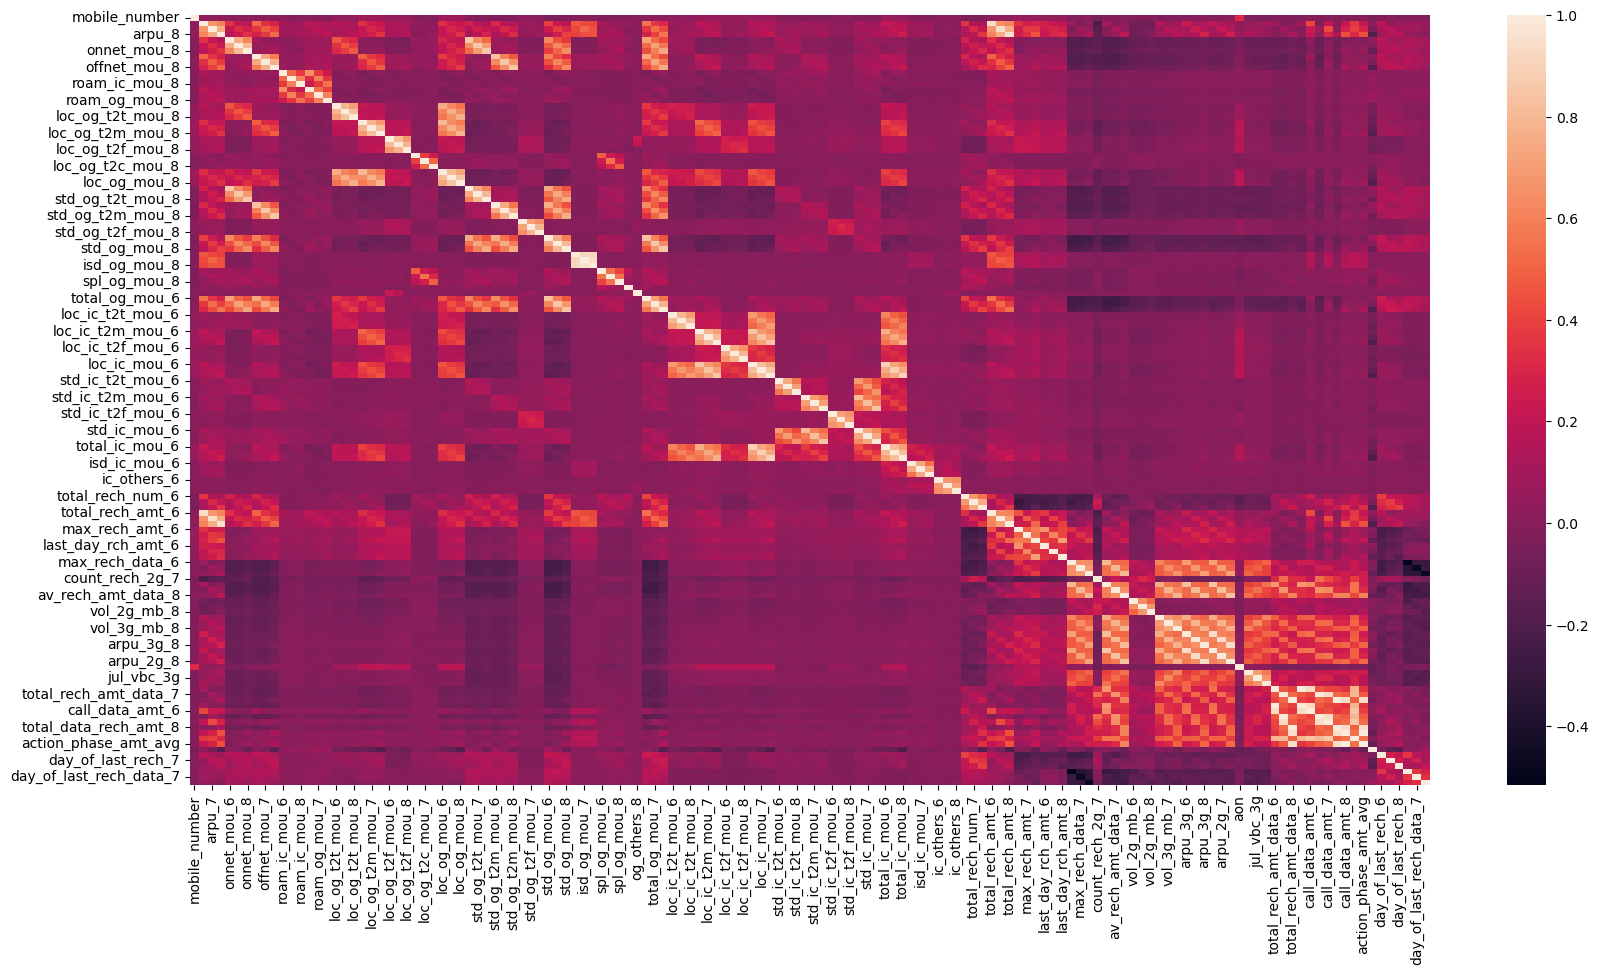

In [56]:
# Define a function that takes a DataFrame and a threshold, and returns a list of highly correlated columns
def get_highly_correlated_columns(df, threshold):
    # Create a correlation matrix with absolute values
    corr_matrix = df.corr().abs()
    # Select the upper triangle of the correlation matrix
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(np.bool))
    # Find the index of the columns that have a correlation greater than the threshold with any other column
    corr_columns = [column for column in upper.columns if any(upper[column] > threshold)]
    # Return the list of highly correlated columns
    return corr_columns

# Apply the function to the df_hvc DataFrame with a threshold of 0.9
corr_cols = get_highly_correlated_columns(telecom_hvc, 0.9)
# Print the list of highly correlated columns
print('Correlated columns : \n {}'.format(corr_cols))

# Create a figure with a specified size
plt.figure(figsize=(20,10))
# Plot a heatmap of the correlation matrix of the tel_numerical_columns_df DataFrame
sns.heatmap(telecom_numerical_col.corr())
# Show the figure
plt.show()


In [57]:
#Dropping columns that are 90% collinear
drop_cols(telecom_hvc, corr_cols)

Dropped columns: isd_og_mou_7, isd_og_mou_8, total_rech_amt_6, total_rech_amt_7, total_rech_amt_8, arpu_2g_6, arpu_2g_7, arpu_2g_8, total_data_rech_amt_6, call_data_amt_6, total_data_rech_amt_7, call_data_amt_7, total_data_rech_amt_8, call_data_amt_8, action_phase_amt_avg


In [58]:
#calling the function we made earlier to redo the column analysis
telecom_numerical_col, telecom_categorical_col = col_analysis(telecom_hvc)

Total numerical columns : 125
Total categorical columns : 0


#### Outlier Treatment 

In [59]:

# define a function to calculate the difference between the 99th and 100th percentile of a data frame
def percentile_diff(df):
  # calculate the 99th and 100th percentile values for each column
  p99 = df.quantile(0.99)
  p100 = df.quantile(1)
  # subtract the 99th percentile values from the 100th percentile values
  diff = p100 - p99
  # sort the results in descending order
  diff = diff.sort_values(ascending=False)
  # return the results
  return diff

In [60]:
telecom_hvc.describe(percentiles=[.25,.5,.75,.90,.95,.98,.99,1])

,mobile_number,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,std_og_t2t_mou_6,std_og_t2t_mou_7,std_og_t2t_mou_8,std_og_t2m_mou_6,std_og_t2m_mou_7,std_og_t2m_mou_8,std_og_t2f_mou_6,std_og_t2f_mou_7,std_og_t2f_mou_8,std_og_mou_6,std_og_mou_7,std_og_mou_8,isd_og_mou_6,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,og_others_6,og_others_8,total_og_mou_6,total_og_mou_7,total_og_mou_8,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,std_ic_t2t_mou_6,std_ic_t2t_mou_7,std_ic_t2t_mou_8,std_ic_t2m_mou_6,std_ic_t2m_mou_7,std_ic_t2m_mou_8,std_ic_t2f_mou_6,std_ic_t2f_mou_7,std_ic_t2f_mou_8,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,ic_others_6,ic_others_7,ic_others_8,total_rech_num_6,total_rech_num_7,total_rech_num_8,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,max_rech_data_6,max_rech_data_7,max_rech_data_8,count_rech_2g_7,av_rech_amt_data_6,av_rech_amt_data_7,av_rech_amt_data_8,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,arpu_3g_6,arpu_3g_7,arpu_3g_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,total_rech_amt_data_6,total_rech_amt_data_7,total_rech_amt_data_8,good_phase_amt_avg,churn,day_of_last_rech_6,day_of_last_rech_7,day_of_last_rech_8,day_of_last_rech_data_6,day_of_last_rech_data_7,day_of_last_rech_data_8
count,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00
mean,7001206159.56,558.49,560.78,508.60,260.79,267.82,234.11,373.69,378.10,335.08,16.11,12.64,12.50,26.57,20.15,19.87,84.48,85.67,78.08,163.24,163.01,151.76,6.34,6.42,5.89,1.58,1.89,1.71,254.08,255.12,235.73,165.89,174.23,148.44,179.43,187.92,157.35,1.80,1.83,1.58,347.13,363.98,307.38,2.17,5.82,7.11,6.56,0.66,0.06,609.87,628.37,551.68,65.45,66.64,62.62,150.41,151.63,146.23,15.28,16.04,14.40,231.15,234.31,223.26,14.89,15.42,13.91,29.20,30.82,27.92,2.70,2.80,2.56,46.79,49.05,44.40,289.95,296.76,279.92,10.78,11.88,11.00,1.15,1.50,1.22,11.85,11.72,9.97,169.28,172.20,160.14,100.89,100.36,92.39,78.08,79.84,72.49,1.40,130.65,139.78,122.13,126.52,125.10,105.91,344.26,370.20,351.49,67.01,68.62,62.77,1209.37,169.14,178.87,158.52,455.78,528.23,463.25,1152.62,0.11,26.47,27.28,26.77,24.51,25.35,25.32
std,690878.42,460.64,479.78,501.96,459.64,479.99,458.45,482.52,498.92,482.06,76.30,75.79,74.13,116.21,96.10,104.72,228.79,240.53,227.37,250.12,241.58,233.66,22.12,21.94,19.50,6.30,9.

In [61]:
print(percentile_diff(telecom_hvc))

total_rech_amt_data_6     100479.00
total_rech_amt_data_8      83367.94
good_phase_amt_avg         55145.50
total_rech_amt_data_7      48888.00
vol_3g_mb_6                41989.47
arpu_7                     33146.33
arpu_8                     31557.00
vol_3g_mb_8                26094.42
arpu_6                     25745.97
mobile_number              25385.00
vol_3g_mb_7                24089.92
std_og_t2m_mou_8           12056.33
offnet_mou_8               11814.21
std_og_mou_8               11210.70
aug_vbc_3g                 10951.22
total_og_mou_8             10823.25
loc_og_t2t_mou_8            9839.23
vol_2g_mb_8                 9669.87
loc_og_mou_8                9377.10
jun_vbc_3g                  9219.92
loc_og_mou_6                8854.59
vol_2g_mb_6                 8742.93
onnet_mou_8                 8593.45
total_og_mou_7              8084.35
std_og_mou_7                8074.19
total_og_mou_6              7478.74
offnet_mou_7                7256.24
std_og_t2m_mou_7            

**Interpretation**
The difference between 100th percentile and 99th percentile is pretty steep for columns like total recharge amount, arpu (average revenue per user) but there isn't a large difference between 98th and 99th percentile

We will remove outliers using percentile technique and cap the outliers at 99 perentile. This way we will preserve most of the data distribution while reducing the influence of the extreme values 

In [62]:
# A function to cap outliers at .99
def cap_outliers(array, k=3):
    upper_limit = array.mean() + k*array.std()
    lower_limit = array.mean() - k*array.std()
    array[array<lower_limit] = lower_limit
    array[array>upper_limit] = upper_limit
    return array

# get the numeric columns for outlier treatment
outliers_cols=telecom_hvc.select_dtypes(include=['float64','int64']).columns.tolist()


In [63]:
#applying the cap for the dataframe
telecom_hvc[outliers_cols] = telecom_hvc[outliers_cols].apply(cap_outliers, axis=0)


In [64]:
#checking the difference between the 99th and new 100th percentile
print(percentile_diff(telecom_hvc))

mobile_number             25385.00
aon                         431.40
isd_og_mou_6                101.45
std_ic_t2t_mou_7             41.51
std_ic_t2t_mou_6             39.57
arpu_8                       27.86
ic_others_7                  23.75
ic_others_6                  23.13
ic_others_8                  18.06
isd_ic_mou_7                 17.08
isd_ic_mou_6                 16.71
std_ic_t2f_mou_8             16.32
std_ic_t2t_mou_8             13.35
og_others_8                  10.00
std_ic_t2f_mou_6              8.62
std_ic_t2f_mou_7              7.85
og_others_6                   4.09
loc_og_t2c_mou_7              1.39
std_og_t2f_mou_7              1.13
arpu_7                        0.61
total_rech_amt_data_6         0.00
day_of_last_rech_7            0.00
total_rech_amt_data_8         0.00
total_rech_num_7              0.00
total_rech_num_6              0.00
good_phase_amt_avg            0.00
churn                         0.00
day_of_last_rech_6            0.00
isd_ic_mou_8        

In [65]:
telecom_hvc.describe(percentiles=[.25,.5,.75,.90,.95,.98,.99,1])

,mobile_number,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,onnet_mou_8,offnet_mou_6,offnet_mou_7,offnet_mou_8,roam_ic_mou_6,roam_ic_mou_7,roam_ic_mou_8,roam_og_mou_6,roam_og_mou_7,roam_og_mou_8,loc_og_t2t_mou_6,loc_og_t2t_mou_7,loc_og_t2t_mou_8,loc_og_t2m_mou_6,loc_og_t2m_mou_7,loc_og_t2m_mou_8,loc_og_t2f_mou_6,loc_og_t2f_mou_7,loc_og_t2f_mou_8,loc_og_t2c_mou_6,loc_og_t2c_mou_7,loc_og_t2c_mou_8,loc_og_mou_6,loc_og_mou_7,loc_og_mou_8,std_og_t2t_mou_6,std_og_t2t_mou_7,std_og_t2t_mou_8,std_og_t2m_mou_6,std_og_t2m_mou_7,std_og_t2m_mou_8,std_og_t2f_mou_6,std_og_t2f_mou_7,std_og_t2f_mou_8,std_og_mou_6,std_og_mou_7,std_og_mou_8,isd_og_mou_6,spl_og_mou_6,spl_og_mou_7,spl_og_mou_8,og_others_6,og_others_8,total_og_mou_6,total_og_mou_7,total_og_mou_8,loc_ic_t2t_mou_6,loc_ic_t2t_mou_7,loc_ic_t2t_mou_8,loc_ic_t2m_mou_6,loc_ic_t2m_mou_7,loc_ic_t2m_mou_8,loc_ic_t2f_mou_6,loc_ic_t2f_mou_7,loc_ic_t2f_mou_8,loc_ic_mou_6,loc_ic_mou_7,loc_ic_mou_8,std_ic_t2t_mou_6,std_ic_t2t_mou_7,std_ic_t2t_mou_8,std_ic_t2m_mou_6,std_ic_t2m_mou_7,std_ic_t2m_mou_8,std_ic_t2f_mou_6,std_ic_t2f_mou_7,std_ic_t2f_mou_8,std_ic_mou_6,std_ic_mou_7,std_ic_mou_8,total_ic_mou_6,total_ic_mou_7,total_ic_mou_8,isd_ic_mou_6,isd_ic_mou_7,isd_ic_mou_8,ic_others_6,ic_others_7,ic_others_8,total_rech_num_6,total_rech_num_7,total_rech_num_8,max_rech_amt_6,max_rech_amt_7,max_rech_amt_8,last_day_rch_amt_6,last_day_rch_amt_7,last_day_rch_amt_8,max_rech_data_6,max_rech_data_7,max_rech_data_8,count_rech_2g_7,av_rech_amt_data_6,av_rech_amt_data_7,av_rech_amt_data_8,vol_2g_mb_6,vol_2g_mb_7,vol_2g_mb_8,vol_3g_mb_6,vol_3g_mb_7,vol_3g_mb_8,arpu_3g_6,arpu_3g_7,arpu_3g_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,total_rech_amt_data_6,total_rech_amt_data_7,total_rech_amt_data_8,good_phase_amt_avg,churn,day_of_last_rech_6,day_of_last_rech_7,day_of_last_rech_8,day_of_last_rech_data_6,day_of_last_rech_data_7,day_of_last_rech_data_8
count,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00,30001.00
mean,7001206159.56,548.19,550.81,498.44,244.52,251.24,216.62,358.67,362.07,319.43,12.32,9.18,9.22,20.59,14.99,14.90,73.43,74.17,67.99,154.59,155.17,144.00,5.47,5.55,5.06,1.31,1.59,1.42,241.06,242.37,223.98,150.31,158.57,131.56,162.59,170.12,140.22,1.26,1.25,1.09,329.83,345.58,287.33,1.30,5.15,6.36,5.77,0.61,0.02,593.48,611.01,533.00,58.32,59.01,55.27,142.38,143.69,138.69,13.25,13.89,12.48,220.22,223.08,212.70,12.01,12.65,11.17,24.96,26.04,23.65,2.04,2.14,1.95,40.72,42.56,38.25,277.93,283.95,268.06,7.82,8.61,7.71,0.82,1.03,0.86,11.61,11.47,9.74,162.25,164.68,153.83,95.25,94.88,87.40,75.32,77.07,69.85,1.31,125.28,133.67,116.13,113.09,110.83,92.31,311.31,334.68,316.75,60.04,61.09,55.75,1209.27,152.77,161.31,141.55,405.36,466.06,403.19,1096.69,0.11,26.47,27.28,26.77,24.51,25.35,25.32
std,690878.42,356.62,361.12,384.49,371.62,387.61,354.67,405.25,413.55,386.60,41.75,35.65,35.30,66.90,52.51,53.59,133.71,136.28,126.69,199.75,197.19,190.42,12.76,12.82,11.75,3.69,4.58,4.06,30

### Exploratory Data Analysis and Insights 

For purpose of telecom, churn is our target variable. We will perform EDA to generate insights for the bussines 

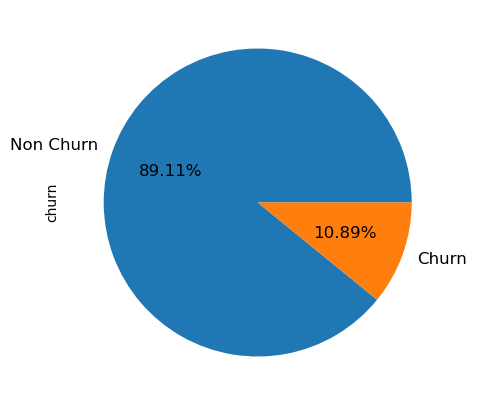

In [66]:
# Plot churn vs Non Churn distribution percentage
plt.figure(figsize = (10,5))
labels ="Non Churn", "Churn"

telecom_hvc["churn"].value_counts().plot.pie(autopct='%1.2f%%',labels=labels, fontsize=12)
plt.show()

**Interpretation**
This pie chart shows that the majority of the customers (73.46%) are non churn, while only 26.54% are churn. This indicates class imbalance too where more data is about non-churn customers than churn customers

In [67]:
# define a function to plot a pairplot of interested columns wrt churn
def plot_pairplot(cols):
  # plot a pairplot with hue as churn 
  sns.pairplot(telecom_hvc[cols], hue='churn', diag_kind='kde',size=4)
  # show the plot
  plt.show()

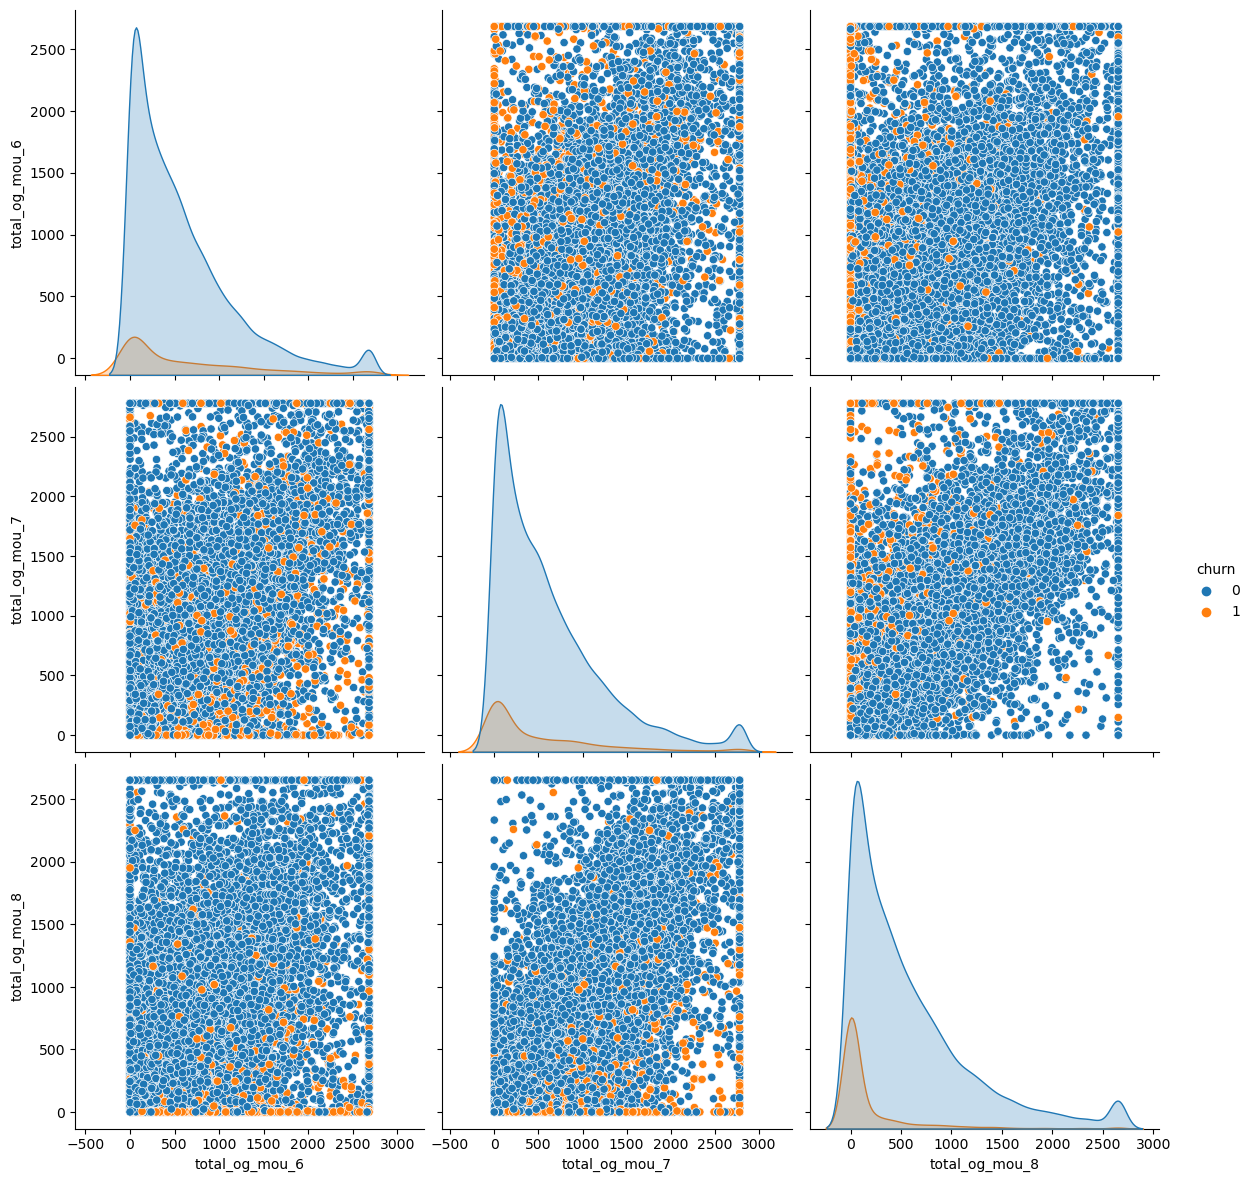

In [68]:
#Outgoing Calls wrt to Churn
cols = ['total_og_mou_6','total_og_mou_7','total_og_mou_8','churn']
plot_pairplot(cols)

**Insights on outgoing call wrt churn**

- The distribution of total_og_mou_6, total_og_mou_7, and total_og_mou_8 are skewed to the right, meaning that most of the customers have low outgoing minutes of usage, while a few have very high outgoing minutes of usage.
- The distribution of churn is imbalanced, meaning that there are more non churn customers than churn customers in the data set.
- The relationship between total_og_mou_6 and total_og_mou_7, and between total_og_mou_7 and total_og_mou_8, are positive and linear, meaning that the customers who have high outgoing minutes of usage in one month tend to have high outgoing minutes of usage in the next month as well.

- The relationship between total_og_mou_6 and total_og_mou_8, and between total_og_mou_7 and churn, are negative and nonlinear, meaning that the customers who have high outgoing minutes of usage in the earlier months tend to have low outgoing minutes of usage in the later months.

- The relationship between total_og_mou_8 and churn is positive and nonlinear, meaning that the customers who have high outgoing minutes of usage in the last month tend to churn less.

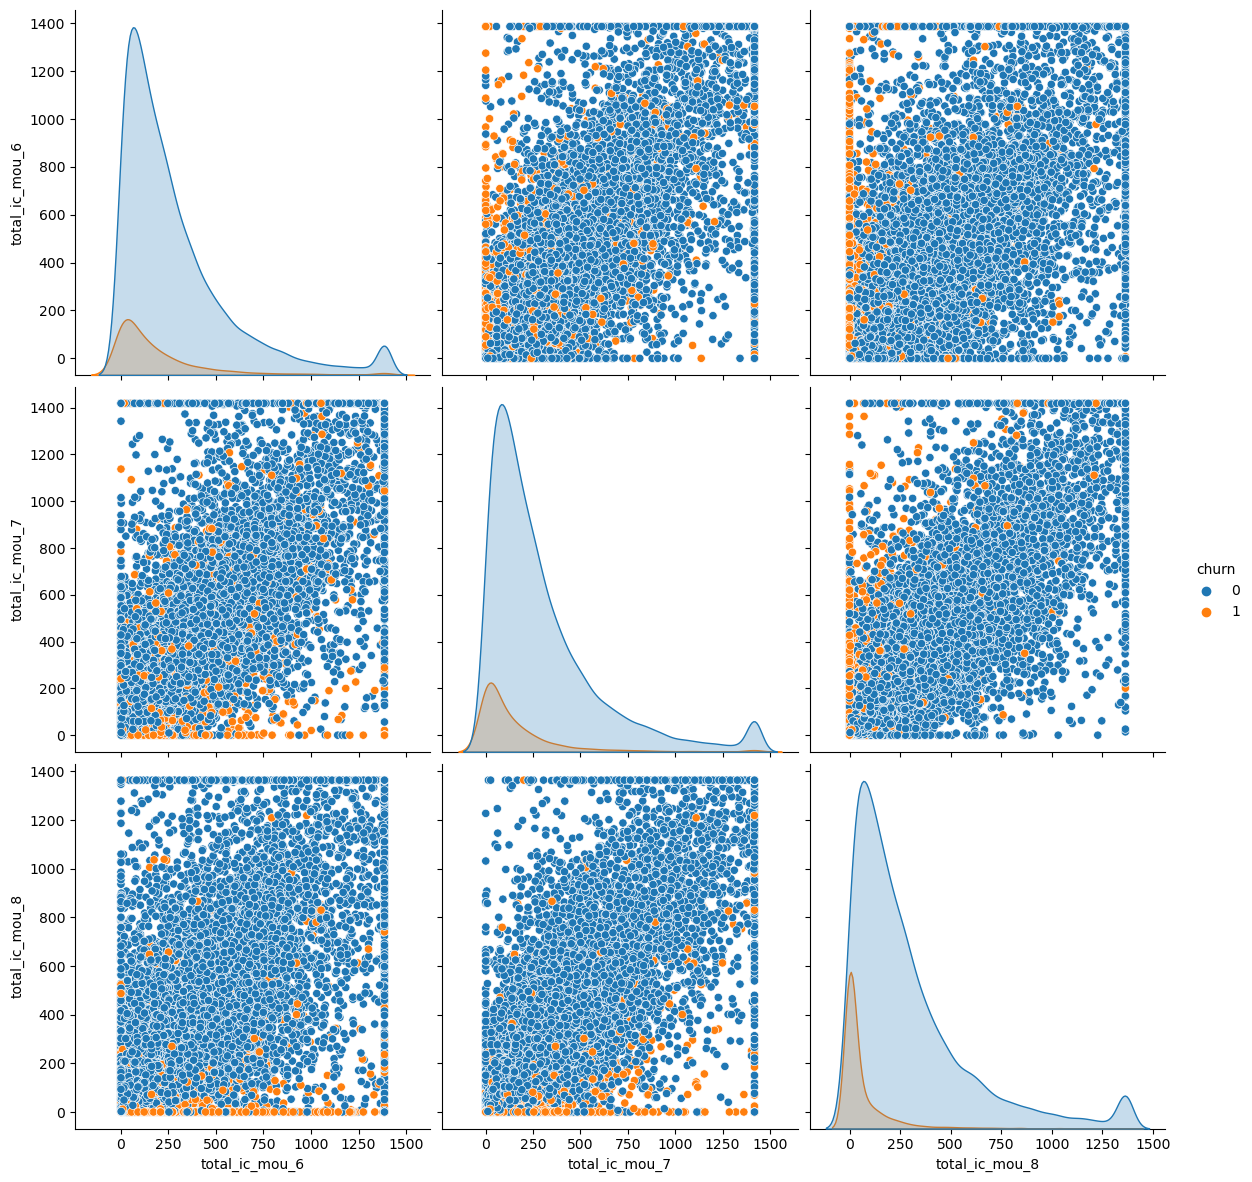

In [69]:
#Incoming Calls wrt to Churn
cols = ['total_ic_mou_6','total_ic_mou_7','total_ic_mou_8','churn']
plot_pairplot(cols)

**Insights on Incoming calls wrt churn**
- The distribution of total_ic_mou_6, total_ic_mou_7, and total_ic_mou_8 are skewed to the right, meaning that most of the customers have low incoming minutes of usage, while a few have very high incoming minutes of usage.
- The distribution of churn is imbalanced, meaning that there are more non churn customers than churn customers in the data set.
- The relationship between total_ic_mou_6 and total_ic_mou_7, and between total_ic_mou_7 and total_ic_mou_8, are positive and linear, meaning that the customers who have high incoming minutes of usage in one month tend to have high incoming minutes of usage in the next month as well.
- The relationship between total_ic_mou_6 and total_ic_mou_8, and between total_ic_mou_7 and churn, are negative and nonlinear, meaning that the customers who have high incoming minutes of usage in the earlier months tend to have low incoming minutes of usage in the later months, or tend to churn more.
- The relationship between total_ic_mou_8 and churn is positive and nonlinear, meaning that the customers who have high incoming minutes of usage in the last month tend to churn less.



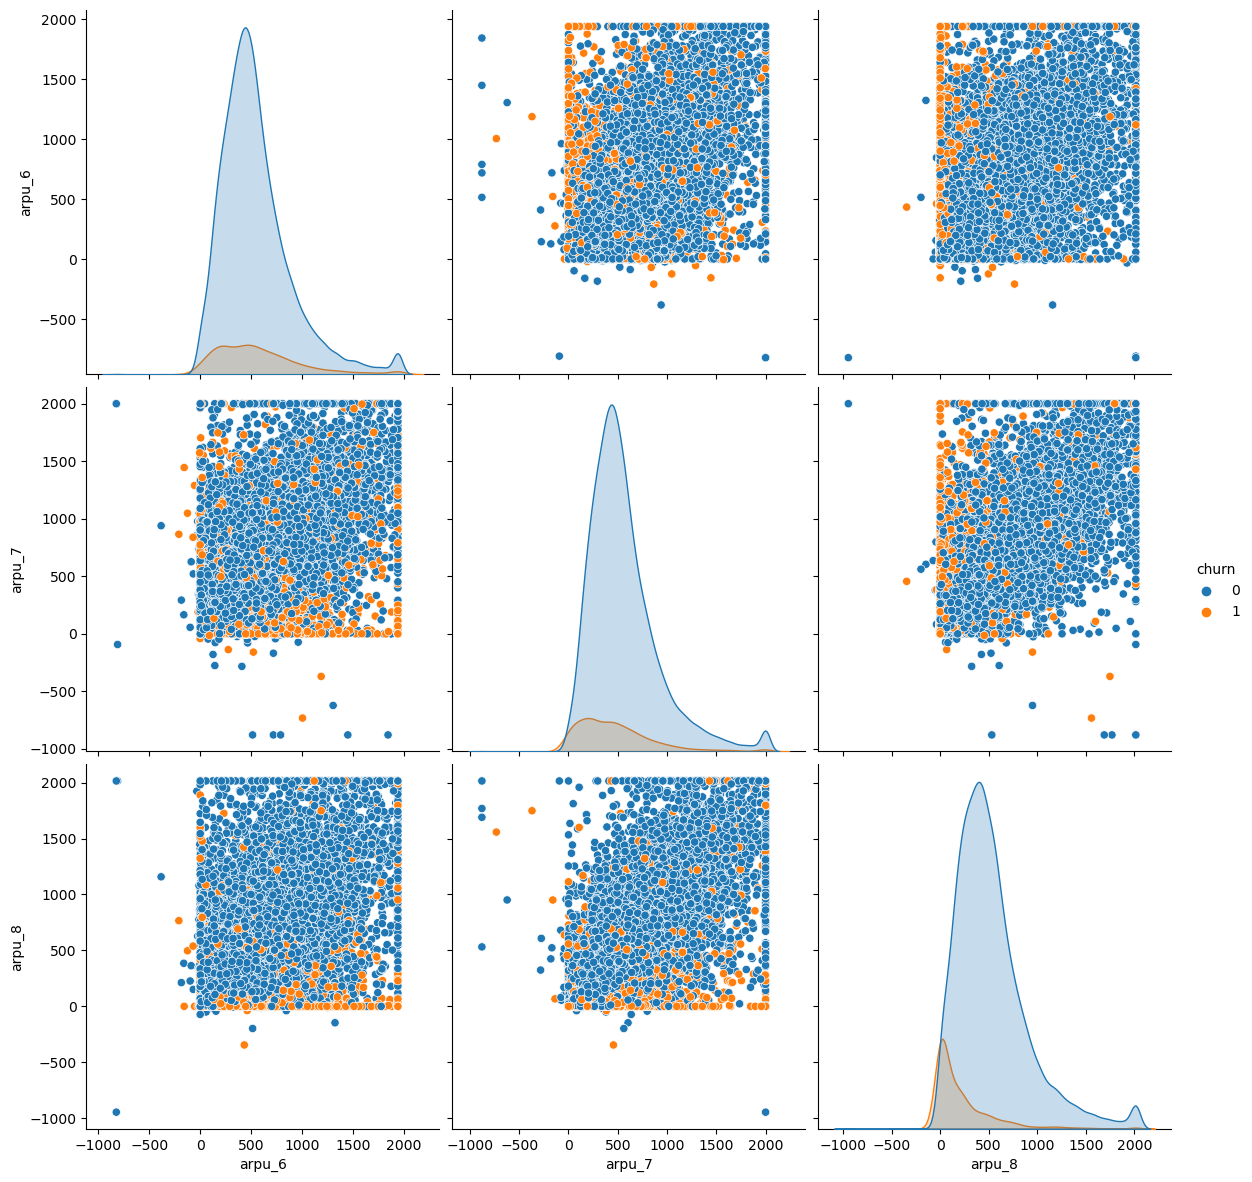

In [70]:
### Average revenue per user wrt churn
cols = ['arpu_6', 'arpu_7', 'arpu_8','churn']
plot_pairplot(cols)

**Insights on arpu wrt churn**
- The relationship between arpu_8 is lower when compared to the arpu_6 and arpu_7 as the churning customers are now generating less average revenue per user
- The non-churning customers also contribute less to the revenue in the arpu_8 (action phase) 

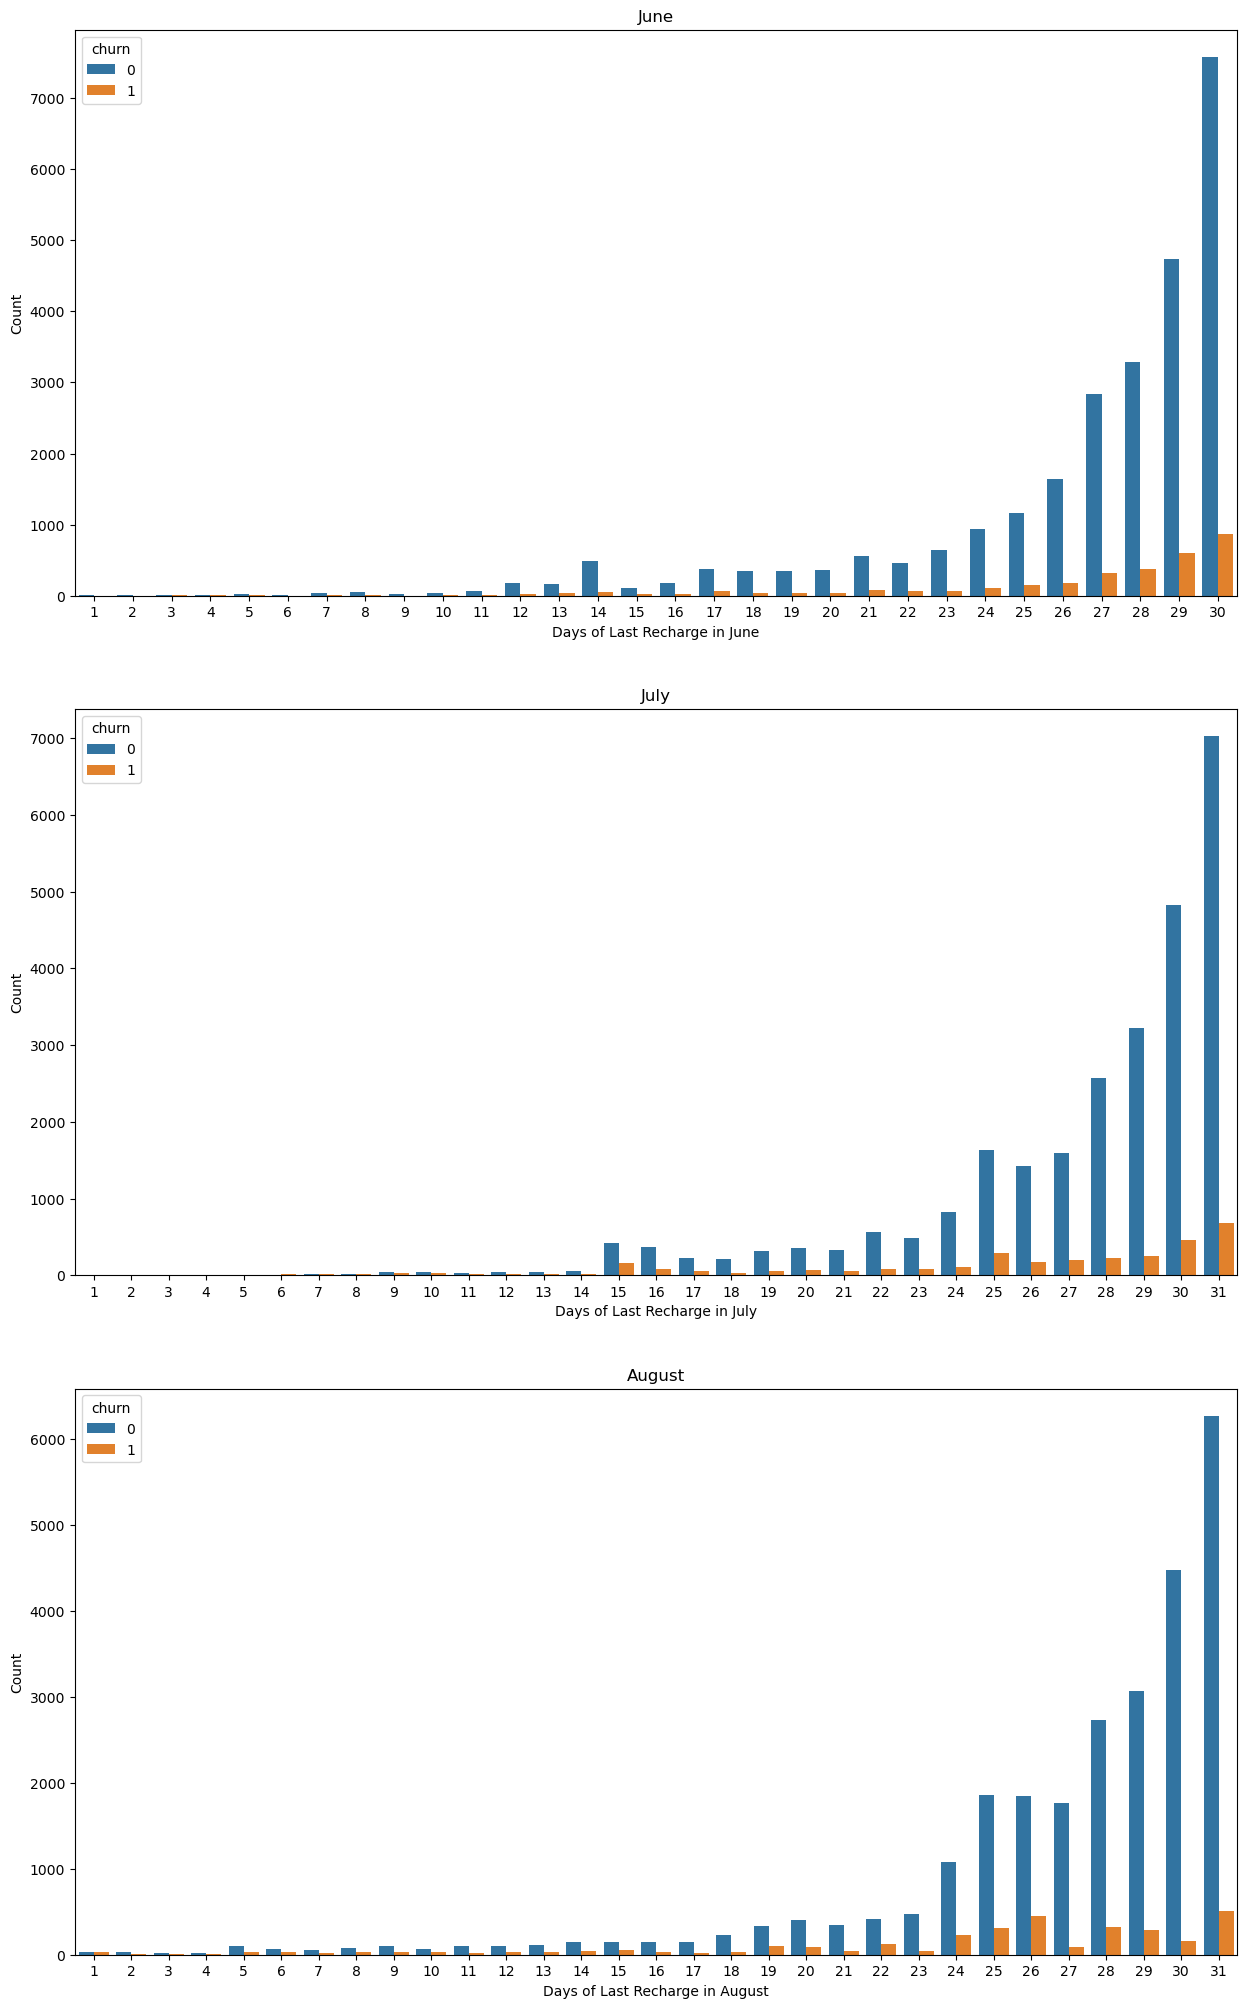

In [71]:
# Create a 1x3 grid of subplots
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(15, 25))

# Plot for June
sns.countplot(x="day_of_last_rech_6", data=telecom_hvc, ax=axs[0], hue="churn")
axs[0].set_xlabel('Days of Last Recharge in June')
axs[0].set_ylabel('Count')
axs[0].set_title('June')

# Plot for July
sns.countplot(x="day_of_last_rech_7", data=telecom_hvc, ax=axs[1], hue="churn")
axs[1].set_xlabel('Days of Last Recharge in July')
axs[1].set_ylabel('Count')
axs[1].set_title('July')

# Plot for August
sns.countplot(x="day_of_last_rech_8", data=telecom_hvc, ax=axs[2], hue="churn")
axs[2].set_xlabel('Days of Last Recharge in August')
axs[2].set_ylabel('Count')
axs[2].set_title('August')

# Show the combined plot
plt.show()

**insights on last recharge amount by June, July and August**

There is a spike in recharges on the last day of each month however this behavior is likely due to imputing the missing vcalues wiht last date by default
- For Non-churn customers: the days leading to the last day, the customers tend to recharge more often during the last week of each month. This pattern can indidcate the users behavior on how they plan to recharge their phones. Therefore, running offers during this period could also positively impact loyalty 
- Churning customers suggest less variability in their days of last recharge which means the days leading to the last day, they have already decided to switch over. 
 

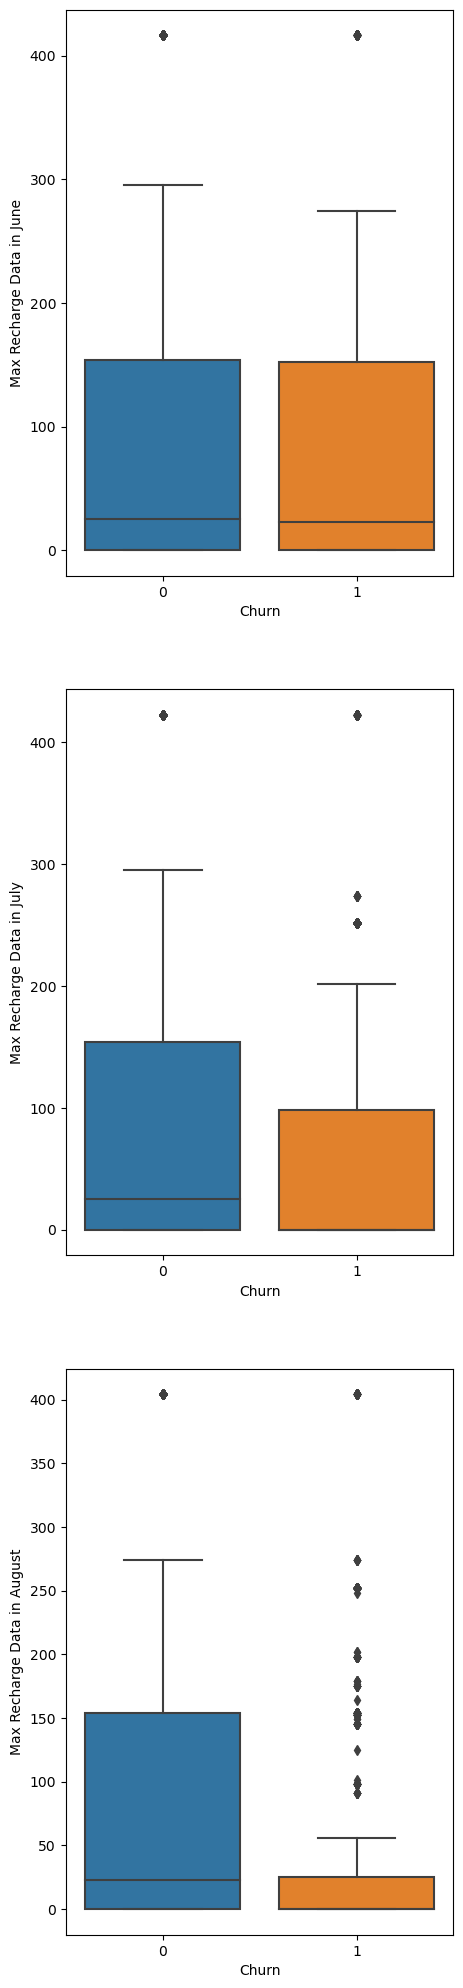

In [72]:
# Maximum recharge on data wrt churn

# Create a 1x3 grid of subplots
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(5, 25))

# Plot for max_rech_data_6
sns.boxplot(x='churn', y='max_rech_data_6', data=telecom_hvc, ax=axs[0])
axs[0].set_xlabel('Churn')
axs[0].set_ylabel('Max Recharge Data in June')

# Plot for max_rech_data_7
sns.boxplot(x='churn', y='max_rech_data_7', data=telecom_hvc, ax=axs[1])
axs[1].set_xlabel('Churn')
axs[1].set_ylabel('Max Recharge Data in July')

# Plot for max_rech_data_8
sns.boxplot(x='churn', y='max_rech_data_8', data=telecom_hvc, ax=axs[2])
axs[2].set_xlabel('Churn')
axs[2].set_ylabel('Max Recharge Data in August')


# Show the combined plot
plt.show()

**insights on maximum recharge amount wrt churn**
- max_rech_data_6: Non-churned users have a higher median value (closer to the top of the box) compared to churned users.The IQR for non-churned users is wider, indicating more variability. Some outliers exist for both groups.
- max_rech_data_7: Similar pattern as in June. Non-churned users have higher median values. Outliers are visible for both groups.
- max_rech_data_8: Again, non-churned users have higher median values. The spread (IQR) is narrower for both groups. Fewer outliers compared to the previous months.

Users who churn tend to have lower maximum recharge data values. Offering incentives (such as extra data or discounts) might help retain customers.

<Axes: xlabel='churn', ylabel='aon'>

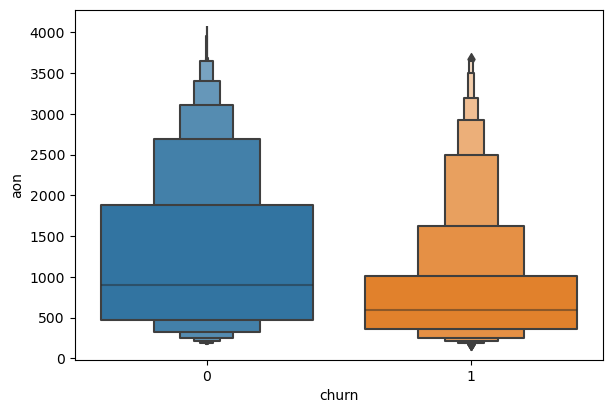

In [73]:
### Age on Network wrt churn 

fig = plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
sns.boxenplot(x='churn', y='aon', data = telecom_hvc)

**insights on average age on network wrt churn"

- Non-churned users tend to have higher average age on network (higher median), therefore as the age on the network increases, the chances of them churning out also reduces. 
- Churned users exhibit lower median compared to the non churned customer (narrower IQR).

In [74]:
# loop over all variables and print the names and sizes of dataframes
for var in dir():
    if isinstance(eval(var), pd.core.frame.DataFrame):
        print(var, eval(var).shape)

_11 (12, 3)
_15 (5, 5)
_18 (10, 5)
_2 (5, 226)
_22 (5, 183)
_3 (8, 214)
_31 (5, 81)
_32 (5, 170)
_43 (5, 6)
_44 (5, 6)
_48 (5, 15)
_6 (6, 1)
_60 (13, 125)
_65 (13, 125)
_9 (6, 1)
__ (13, 125)
___ (13, 125)
df (6, 1)
missing_values (183, 2)
telecom (99999, 238)
telecom_categorical_col (30001, 0)
telecom_hvc (30001, 125)
telecom_numerical_col (30001, 125)
variance_df (164, 3)
zero_value_pct_df (2, 164)


In [75]:
# deleting intermediate df to release memory

del telecom
del telecom_categorical_col
del telecom_numerical_col
del variance_df


## Modelling (Churn Prediction)

#### Model data preparation
- Dividing data set into target variable vs independent variabkes
- Splitting into test and training data sets
- Class Balancing
- Scaling data using Standard Scaler and Incremental PCA

In [76]:
### Dividing Training data into X and Y sets for model building

X = telecom_hvc[telecom_hvc.columns[~telecom_hvc.columns.isin(['churn'])]]
y = telecom_hvc['churn']

In [77]:
# Count the number of features
features = list(X.columns)
print('Total features : {}'.format(len(features)))

Total features : 124


In [78]:
### Splitting into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, train_size = 0.7, random_state = 100)


In [79]:
# Analyzing class imbalance by Calculating percentages
train_churn_pct = calculate_percentage(len(y_train[y_train == 1]), len(y_train))
train_nonchurn_pct = calculate_percentage(len(y_train[y_train == 0]), len(y_train))
test_churn_pct = calculate_percentage(len(y_test[y_test == 1]), len(y_test))
test_nonchurn_pct = calculate_percentage(len(y_test[y_test == 0]), len(y_test))

# Create a dictionary with the data
data = {'Data Type': ['Training Data', 'Training Data', 'Test Data', 'Test Data'],
        'Shape': [X_train.shape, y_train.shape, X_test.shape, y_test.shape],
        'Churn Percentage': [train_churn_pct, train_nonchurn_pct, test_churn_pct, test_nonchurn_pct]}

# Convert the dictionary to a pandas dataframe
df = pd.DataFrame(data)

# Print the dataframe with class imbalance data 
print(df)

       Data Type         Shape  Churn Percentage
0  Training Data  (21000, 124)             10.87
1  Training Data      (21000,)             89.13
2      Test Data   (9001, 124)             10.93
3      Test Data       (9001,)             89.07


**Interpretation**
Both training and test data have extreme imbalanced with 10.87% data representing the churn class and the rest non-churn class. I am chosing smote technique to perform class balancing. 


In [80]:
from imblearn.over_sampling import SMOTE

def perform_smote(X_train, y_train):
    sm = SMOTE(random_state=100)
    X_smote, y_smote = sm.fit_resample(X_train, y_train)
    X_train_smote = pd.DataFrame(X_smote, columns=X_train.columns)
    y_train_smote = pd.Series(y_smote)
    print('After SMOTE, total values per class in training data : \n {} \n'
          .format(y_train_smote.value_counts()))
    return X_train_smote, y_train_smote

# Balancing train dataset
X_train_smote, y_train_smote = perform_smote(X_train, y_train)


After SMOTE, total values per class in training data : 
 0    18718
1    18718
Name: churn, dtype: int64 



In [81]:
# Functions to do standard scaling and performing PCA on it
def standard_scaling(X_train, X_test):
    scaler = StandardScaler()
    # Perform Fit and Transform on Training Data
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns = X_train.columns)

    # Perform only Transform on Test Data
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns = X_test.columns)
    
    return X_train_scaled, X_test_scaled

# Perform PCA
def perform_pca(X_train, X_test, scaled = False, incremental_pca = False, n_components = 60):
    if incremental_pca:
        pca = IncrementalPCA(n_components = n_components)
    else:
        pca = PCA(svd_solver='randomized', random_state = 100)
    
    if scaled:
        X_train_scaled = X_train.copy()
        X_test_scaled = X_test.copy()
    else:
        X_train_scaled, X_test_scaled = standard_scaling(X_train, X_test)

    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    return pca, X_train_pca, X_test_pca

In [82]:
#Function that summarizes the performance of the model

from tabulate import tabulate

def summarize_model(y_true, y_pred):
    false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_pred)
    roc_auc = auc(false_positive_rate, true_positive_rate)
    
    data = [['False Positive Rate', false_positive_rate],
            ['True Positive Rate', true_positive_rate],
            ['Thresholds', thresholds],
            ['ROC AUC Score', roc_auc],
            ['Accuracy Score', accuracy_score(y_true, y_pred)],
            ['Precision Score', precision_score(y_true, y_pred)],
            ['Recall Score', recall_score(y_true, y_pred)],
            ['F1 Score', f1_score(y_true, y_pred)],
            ['Confusion Matrix', confusion_matrix(y_true, y_pred)],
            ['Classification Report', classification_report(y_true, y_pred)]]
    
    headers = ['Metric', 'Value']
    
    print(tabulate(data, headers=headers, tablefmt='grid'))
    
    plt.figure(figsize=(6, 6))
    plt.plot(false_positive_rate, true_positive_rate, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic example')
    plt.legend(loc="lower right")
    plt.show()


#### Model Building

Our data set has 30K observations (data points) and close to 125 features (dimensions). PCA would help us reduce dimensionality by fiding q dimensional subspace that captuees most information while minimizing information loss. 

In [83]:
from sklearn.decomposition import PCA, IncrementalPCA 

# Lets initialize PCA
default_incremental_pca = IncrementalPCA()

+-----------------------+-------------------------------------------------------+
| Metric                | Value                                                 |
+=======================+=======================================================+
| False Positive Rate   | [0. 1.]                                               |
+-----------------------+-------------------------------------------------------+
| True Positive Rate    | [0. 1.]                                               |
+-----------------------+-------------------------------------------------------+
| Thresholds            | [1 0]                                                 |
+-----------------------+-------------------------------------------------------+
| ROC AUC Score         | 0.5                                                   |
+-----------------------+-------------------------------------------------------+
| Accuracy Score        | 0.8906788134651705                                    |
+---------------

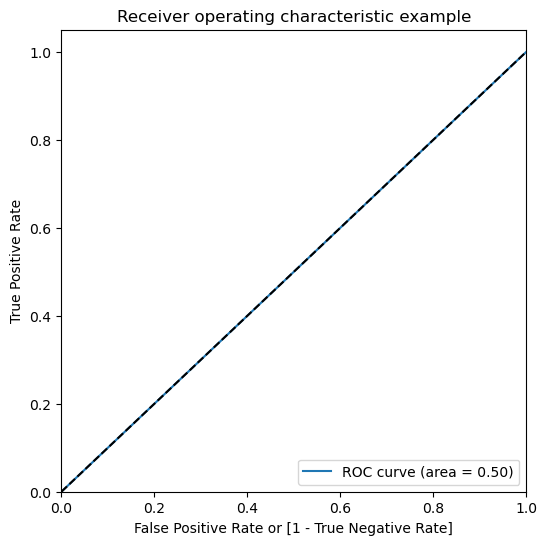

In [84]:
#### Logistics Regression on training data with PCA

log_reg_default_model = LogisticRegression()
log_reg_default_model.fit(X_train, y_train)

y_pred_log_reg_default = log_reg_default_model.predict(X_test)

summarize_model(y_test, y_pred_log_reg_default)

+-----------------------+-------------------------------------------------------+
| Metric                | Value                                                 |
+=======================+=======================================================+
| False Positive Rate   | [0.       0.020706 1.      ]                          |
+-----------------------+-------------------------------------------------------+
| True Positive Rate    | [0.        0.3699187 1.       ]                       |
+-----------------------+-------------------------------------------------------+
| Thresholds            | [2 1 0]                                               |
+-----------------------+-------------------------------------------------------+
| ROC AUC Score         | 0.6746063497182309                                    |
+-----------------------+-------------------------------------------------------+
| Accuracy Score        | 0.9126763692923009                                    |
+---------------

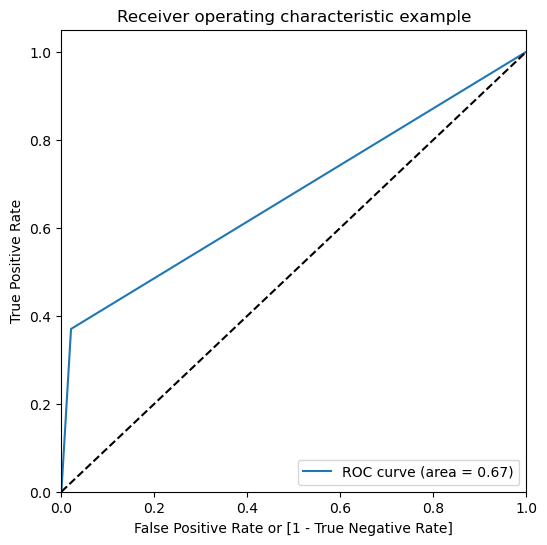

In [85]:
### Logistics Regression on training data with PCA

log_reg_default_pca, X_train_log_reg_default_pca, X_test_log_reg_default_pca = perform_pca(X_train, X_test)

log_reg_default_pca_model = LogisticRegression()
log_reg_default_pca_model.fit(X_train_log_reg_default_pca, y_train)

y_pred_log_reg_pca_default = log_reg_default_pca_model.predict(X_test_log_reg_default_pca)

summarize_model(y_test, y_pred_log_reg_pca_default)

+-----------------------+-------------------------------------------------------+
| Metric                | Value                                                 |
+=======================+=======================================================+
| False Positive Rate   | [0. 1.]                                               |
+-----------------------+-------------------------------------------------------+
| True Positive Rate    | [0. 1.]                                               |
+-----------------------+-------------------------------------------------------+
| Thresholds            | [1 0]                                                 |
+-----------------------+-------------------------------------------------------+
| ROC AUC Score         | 0.5                                                   |
+-----------------------+-------------------------------------------------------+
| Accuracy Score        | 0.8906788134651705                                    |
+---------------

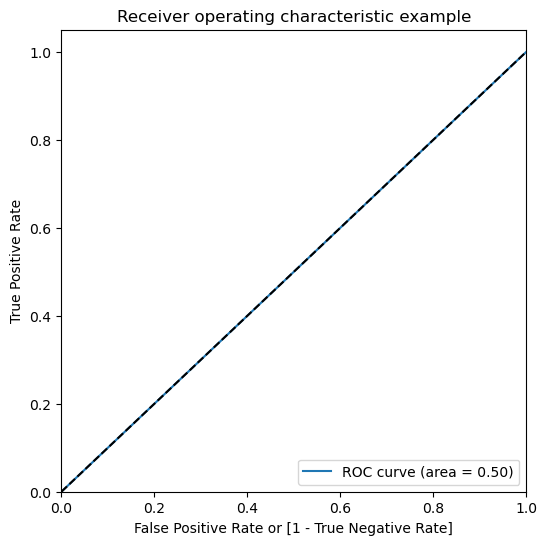

In [86]:
#### Logistics Regression with SMOTE training data and Without PCA

log_reg_smote_default_model = LogisticRegression()
log_reg_smote_default_model.fit(X_train_smote, y_train_smote)

y_pred_log_reg_smote_default = log_reg_smote_default_model.predict(X_test)

summarize_model(y_test, y_pred_log_reg_smote_default)

+-----------------------+-------------------------------------------------------+
| Metric                | Value                                                 |
+=======================+=======================================================+
| False Positive Rate   | [0.         0.16302856 1.        ]                    |
+-----------------------+-------------------------------------------------------+
| True Positive Rate    | [0.         0.80589431 1.        ]                    |
+-----------------------+-------------------------------------------------------+
| Thresholds            | [2 1 0]                                               |
+-----------------------+-------------------------------------------------------+
| ROC AUC Score         | 0.8214328723211144                                    |
+-----------------------+-------------------------------------------------------+
| Accuracy Score        | 0.8335740473280746                                    |
+---------------

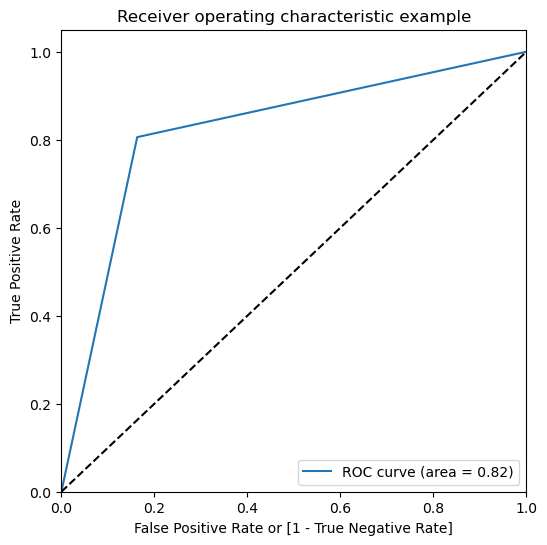

In [87]:
#### Logistics Regression with SMOTE training data and with PCA
log_reg_smote_default_pca,\
X_train_log_reg_smote_default_pca, X_test_log_reg_smote_default_pca = perform_pca(X_train_smote, X_test)

log_reg_smote_default_pca_model = LogisticRegression()
log_reg_smote_default_pca_model.fit(X_train_log_reg_smote_default_pca, y_train_smote)

y_pred_log_reg_smote_default_pca = log_reg_smote_default_pca_model.predict(X_test_log_reg_smote_default_pca)

summarize_model(y_test, y_pred_log_reg_smote_default_pca)

**Interpretations**

SMOTE data with PCA is our best choice for hyperparameter tuning. 



In [88]:
# Function for plotting scree plots

def cumulative_explained_variance_plot(subplot, title, pca):
    subplot.set_xlabel('Principal Component')
    subplot.set_ylabel('Cumulative Explained Variance')
    subplot.set_title(title)
    subplot.plot(np.cumsum(log_reg_default_pca.explained_variance_ratio_))

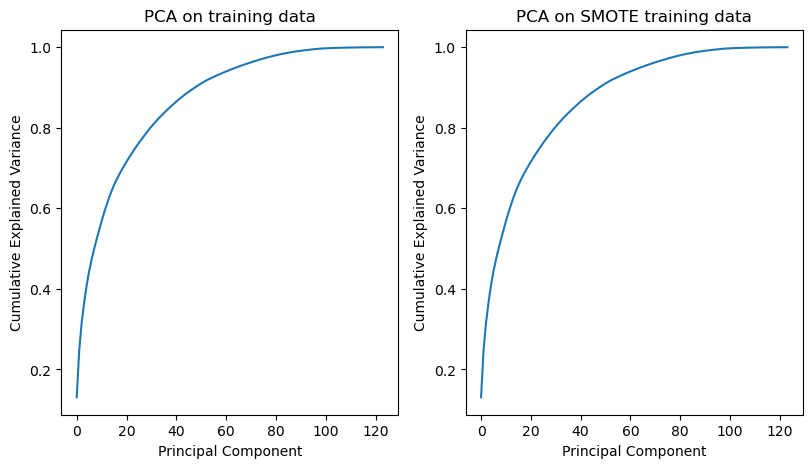

In [89]:
# Draw Scree Plot

fig = plt.figure(figsize = (20,5))

pca_subplot1 = fig.add_subplot(141)
cumulative_explained_variance_plot(pca_subplot1, 'PCA on training data', log_reg_default_pca)

pca_subplot2 = fig.add_subplot(142)
cumulative_explained_variance_plot(pca_subplot2, 'PCA on SMOTE training data', log_reg_smote_default_pca)

plt.show()

**Interpretations**

By comparing the scree plots, you can assess how well PCA captures variance in both scenarios. It helps you decide how many principal components to retain for dimensionality reduction or feature selection.4

Both plots show that the curves start to plateau around 80-100 principal components, indicating that additional components do not contribute significantly to explaining more variance. Therefore, retaining around 80-100 principal components could be a good choice for dimensionality reduction.

In [90]:
#Cross checking CEV for Principal components
explained_variance_df = pd.DataFrame(np.cumsum(log_reg_default_pca.explained_variance_ratio_), columns = ['default_cev'])
explained_variance_df['smote_cev'] = np.cumsum(log_reg_smote_default_pca.explained_variance_ratio_)
explained_variance_df.index = np.arange(1, len(explained_variance_df) + 1)

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(explained_variance_df)

,default_cev,smote_cev
1,0.13,0.14
2,0.25,0.25
3,0.32,0.31
4,0.37,0.36
5,0.41,0.40
6,0.44,0.43
7,0.47,0.46
8,0.50,0.49
9,0.52,0.52
10,0.55,0.54


**Interpretation**

A higher CEVV indicates that the corresponding principal component capture more variance in the data. Typically we want to explain 95% of variance. The decision impacts the trade-off between dimensionality reduction and information preservation

In [91]:
## Prepping data with SMOTE data 

X_train_log_reg_smote_scaled, X_test_log_reg_smote_scaled = standard_scaling(X_train_smote,X_test)

In [92]:
#Setting pipeline that would allow us to chain taogether multiple data transformers and predictive model into a single project 

from sklearn.pipeline import Pipeline

log_reg_pca_components = range(6, 61, 10)

log_reg_parameters = {'pca__n_components': log_reg_pca_components}

log_regression = LogisticRegression(n_jobs = -1)

log_reg_pipeline = Pipeline(steps=[('pca', default_incremental_pca),('log_regression', log_regression)])

In [93]:
# Functions to create GRID Search
def create_grid_search(pipeline, parameters, scoring=['precision','recall', 'f1', 'roc_auc'], 
                        cv_fold_split = 5, refit = 'roc_auc'):
    folds = KFold(n_splits = cv_fold_split, shuffle = True, random_state = 100)
    
    display(parameters)

    grid_search = GridSearchCV(pipeline, cv = folds, param_grid = parameters,
                               scoring = scoring,
                               return_train_score = True, verbose = True,
                               refit = refit)
    
    return grid_search

# Function to perform GRID Search
def conduct_grid_search(grid_search, X_train, y_train, display_results = False):
    with parallel_backend('threading'):
        grid_search.fit(X_train, y_train)
        
    print('Best {} score after hyperparameters tuning : {}'.format(grid_search.refit, grid_search.best_score_))
    print('Best parameters after hyperparameters tuning for {} score : {}'\
          .format(grid_search.refit, grid_search.best_params_))

    cv_results = pd.DataFrame(grid_search.cv_results_)
    
    if display_results:
        with pd.option_context('display.max_rows', None, 'display.max_columns', None):
            display(cv_results)
        
    return cv_results

In [94]:
# Create and conduct Grid Search on Logistic Regression Model
from sklearn.utils import resample, parallel_backend 

log_reg_grid_search = create_grid_search(log_reg_pipeline, log_reg_parameters)
log_reg_cv_results = conduct_grid_search(log_reg_grid_search, X_train_log_reg_smote_scaled, y_train_smote)

{'pca__n_components': range(6, 61, 10)}

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best roc_auc score after hyperparameters tuning : 0.9030959994626645
Best parameters after hyperparameters tuning for roc_auc score : {'pca__n_components': 56}


In [95]:
# Function to plot parameters
def plot_hyperparameters_subplot(dataframe, param, ax, xlabel, title = ''):
    if title:
        ax.set_title(title)
    else:
        ax.set_title('{} - AUC Score: Test vs Train'.format(xlabel))
        
    ax.plot(dataframe[param], 
         dataframe.mean_test_roc_auc, color='g')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Mean Test AUC Score', color='g')

    ax2 = ax.twinx()
    ax2.plot(dataframe[param], 
             dataframe.mean_test_recall, color='r')
    ax2.set_ylabel('Mean Test Recall Score', color='r')

def plot_hyperparameters(dataframe, param, xlabel):
    fig = plt.figure(figsize=(10,5))
    ax1 = fig.add_subplot(111)
    plot_hyperparameters_subplot(dataframe, param, ax1, xlabel)
    plt.show()

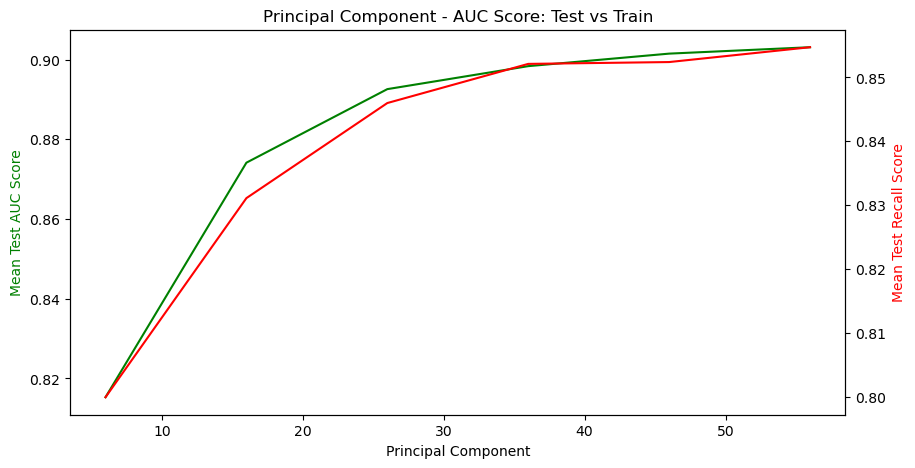

In [96]:
#Validating hyperparameter tuning results
plot_hyperparameters(log_reg_cv_results, 'param_pca__n_components', 'Principal Component')

**Interpretation of the plot**
The green curve represents the test data, and the red curve represents the train data. As the number of PCs increases, both curves rise initially and then stabilize.The point where the test curve peaks or where both curves stabilize can guide the choice of optimal PCs.

Based on this plot, we are selecting the number of principal components that balances good performance (high AUC) and recall (ability to catch positive cases) at 56

#### Final Logistics Regression Model

+-----------------------+-------------------------------------------------------+
| Metric                | Value                                                 |
+=======================+=======================================================+
| False Positive Rate   | [0.         0.16527379 1.        ]                    |
+-----------------------+-------------------------------------------------------+
| True Positive Rate    | [0.         0.81605691 1.        ]                    |
+-----------------------+-------------------------------------------------------+
| Thresholds            | [2 1 0]                                               |
+-----------------------+-------------------------------------------------------+
| ROC AUC Score         | 0.8253915586898166                                    |
+-----------------------+-------------------------------------------------------+
| Accuracy Score        | 0.8326852571936452                                    |
+---------------

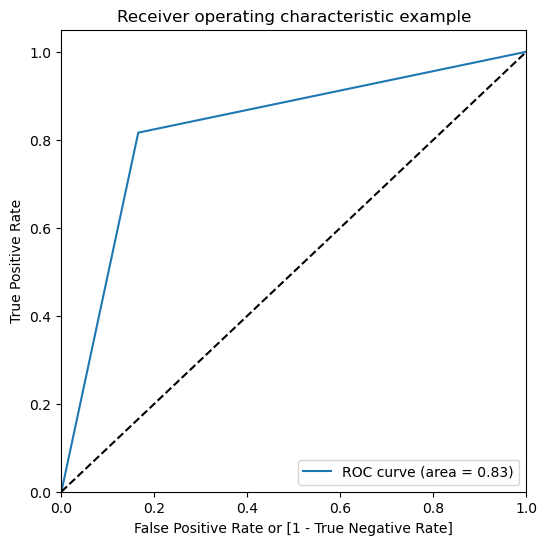

In [97]:
log_reg_pca, X_train_log_reg_pca, X_test_log_reg_pca = perform_pca(X_train_smote, X_test, 
                                                                   incremental_pca = True, n_components = 56)

final_log_reg = LogisticRegression()
final_log_reg.fit(X_train_log_reg_pca, y_train_smote)

y_pred_log_reg = final_log_reg.predict(X_test_log_reg_pca)
summarize_model(y_test, y_pred_log_reg)

**Interpretation of the final logistics regression model**

Essentially, it is plotting the True Positive Rate (TPR) against the False Positive Rate (FPR). An AUC value of 0.82 suggests that the model has a good discriminatory power—it can correctly classify churned and non-churned customers with high accuracy.

+-----------------------+-------------------------------------------------------+
| Metric                | Value                                                 |
+=======================+=======================================================+
| False Positive Rate   | [0.         0.06897842 1.        ]                    |
+-----------------------+-------------------------------------------------------+
| True Positive Rate    | [0.         0.51930894 1.        ]                    |
+-----------------------+-------------------------------------------------------+
| Thresholds            | [2 1 0]                                               |
+-----------------------+-------------------------------------------------------+
| ROC AUC Score         | 0.7251652611168746                                    |
+-----------------------+-------------------------------------------------------+
| Accuracy Score        | 0.8860126652594156                                    |
+---------------

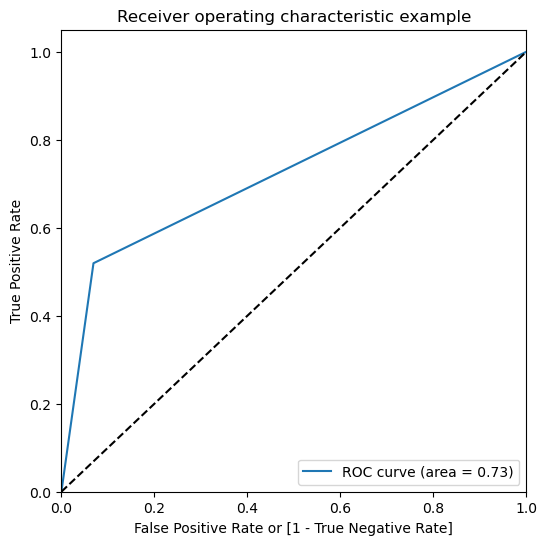

In [98]:
### Decision Tree Classifier with training data and without PCA
default_decision_tree = DecisionTreeClassifier(random_state = 100)

default_decision_tree.fit(X_train, y_train)

y_pred_decision_tree_default = default_decision_tree.predict(X_test)

summarize_model(y_test, y_pred_decision_tree_default)

+-----------------------+-------------------------------------------------------+
| Metric                | Value                                                 |
+=======================+=======================================================+
| False Positive Rate   | [0.         0.09168018 1.        ]                    |
+-----------------------+-------------------------------------------------------+
| True Positive Rate    | [0.         0.36178862 1.        ]                    |
+-----------------------+-------------------------------------------------------+
| Thresholds            | [2 1 0]                                               |
+-----------------------+-------------------------------------------------------+
| ROC AUC Score         | 0.6350542191339339                                    |
+-----------------------+-------------------------------------------------------+
| Accuracy Score        | 0.8485723808465726                                    |
+---------------

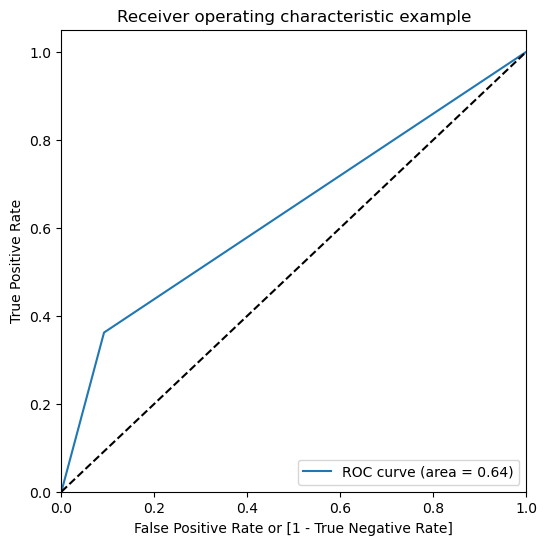

In [99]:
## Decision classifier with training data and with PCA
decision_tree_default_pca,\
X_train_decision_tree_default_pca, X_test_decision_tree_default_pca = perform_pca(X_train, X_test)

default_decision_tree_pca_model = DecisionTreeClassifier(random_state = 100)

default_decision_tree_pca_model.fit(X_train_decision_tree_default_pca, y_train)

y_pred_decision_tree_default_pca = default_decision_tree_pca_model.predict(X_test_decision_tree_default_pca)

summarize_model(y_test, y_pred_decision_tree_default_pca)

+-----------------------+-------------------------------------------------------+
| Metric                | Value                                                 |
+=======================+=======================================================+
| False Positive Rate   | [0.         0.12224024 1.        ]                    |
+-----------------------+-------------------------------------------------------+
| True Positive Rate    | [0.         0.60670732 1.        ]                    |
+-----------------------+-------------------------------------------------------+
| Thresholds            | [2 1 0]                                               |
+-----------------------+-------------------------------------------------------+
| ROC AUC Score         | 0.7422335387910446                                    |
+-----------------------+-------------------------------------------------------+
| Accuracy Score        | 0.8481279857793579                                    |
+---------------

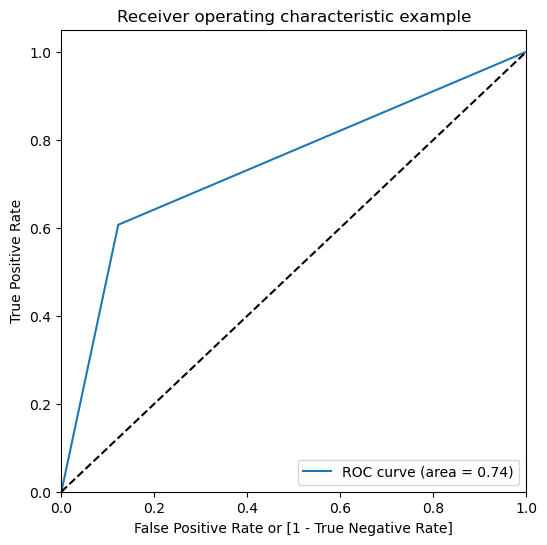

In [100]:
## Decision Classifer with SMOTE training data and without PCA
decision_tree_smote_default_model = DecisionTreeClassifier(random_state = 100)

decision_tree_smote_default_model.fit(X_train_smote, y_train_smote)

y_pred_decision_tree_smote_default = decision_tree_smote_default_model.predict(X_test)

summarize_model(y_test, y_pred_decision_tree_smote_default)


+-----------------------+-------------------------------------------------------+
| Metric                | Value                                                 |
+=======================+=======================================================+
| False Positive Rate   | [0.         0.17612573 1.        ]                    |
+-----------------------+-------------------------------------------------------+
| True Positive Rate    | [0.         0.52337398 1.        ]                    |
+-----------------------+-------------------------------------------------------+
| Thresholds            | [2 1 0]                                               |
+-----------------------+-------------------------------------------------------+
| ROC AUC Score         | 0.6736241254610377                                    |
+-----------------------+-------------------------------------------------------+
| Accuracy Score        | 0.791023219642262                                     |
+---------------

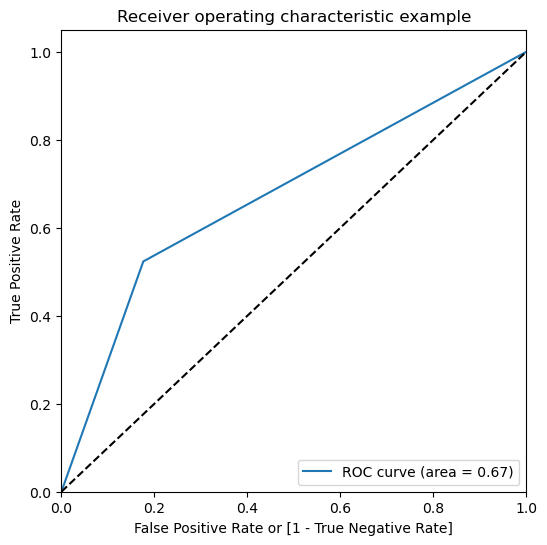

In [101]:
## Decision Classifer with SMOTE Training data and with PCA
decision_tree_smote_default_pca,\
X_train_decision_tree_smote_default_pca,\
X_test_decision_tree_smote_default_pca = perform_pca(X_train_smote, X_test)

decision_tree_smote_default_pca_model = DecisionTreeClassifier(random_state = 100)

decision_tree_smote_default_pca_model.fit(X_train_decision_tree_smote_default_pca, y_train_smote)

y_pred_decision_tree_smote_default_pca = decision_tree_smote_default_pca_model.predict(X_test_decision_tree_smote_default_pca)

summarize_model(y_test, y_pred_decision_tree_smote_default_pca)

**Interpretation on Decision Classifier**

The ROC curve for SMOTE training data without PCA provides overall best performance on predicting churn class. We will be using the same

In [102]:
#Setting up pipeline again
decision_tree_max_depth = range(1, 6, 1)
decision_tree_min_samples_leaf = range(1, 151, 50)

decision_tree_parameters = {'decision_tree__min_samples_leaf': decision_tree_min_samples_leaf,
                            'decision_tree__max_depth': decision_tree_max_depth}

decision_tree = DecisionTreeClassifier(random_state = 100)

decision_tree_pipeline = Pipeline(steps=[('decision_tree', decision_tree)])

In [103]:
### Grid search for hyperparameters tuning
decision_tree_grid_search = create_grid_search(decision_tree_pipeline, decision_tree_parameters)
decision_tree_cv_results = conduct_grid_search(decision_tree_grid_search, X_train_smote, y_train_smote)

{'decision_tree__min_samples_leaf': range(1, 151, 50),
 'decision_tree__max_depth': range(1, 6)}

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best roc_auc score after hyperparameters tuning : 0.9161019521382359
Best parameters after hyperparameters tuning for roc_auc score : {'decision_tree__max_depth': 5, 'decision_tree__min_samples_leaf': 51}


In [104]:
# Function to plot hyperparameters tuning results
def plot_params(dataframe, param, sub_param, param_name, sub_param_name):
    subplots_values = dataframe[param].unique()
    total_subplot_values = len(subplots_values)
    subplot_rows = math.ceil(total_subplot_values /2)
    fig = plt.figure(figsize = (25, subplot_rows * 6))
    for index, param_value in enumerate(subplots_values):
        param_ax1 = fig.add_subplot(subplot_rows, 2, (index + 1))
        plot_hyperparameters_subplot(dataframe[dataframe[param] == param_value], sub_param, 
                   param_ax1, sub_param_name, '{} = {}'.format(param_name, param_value))
    plt.show()

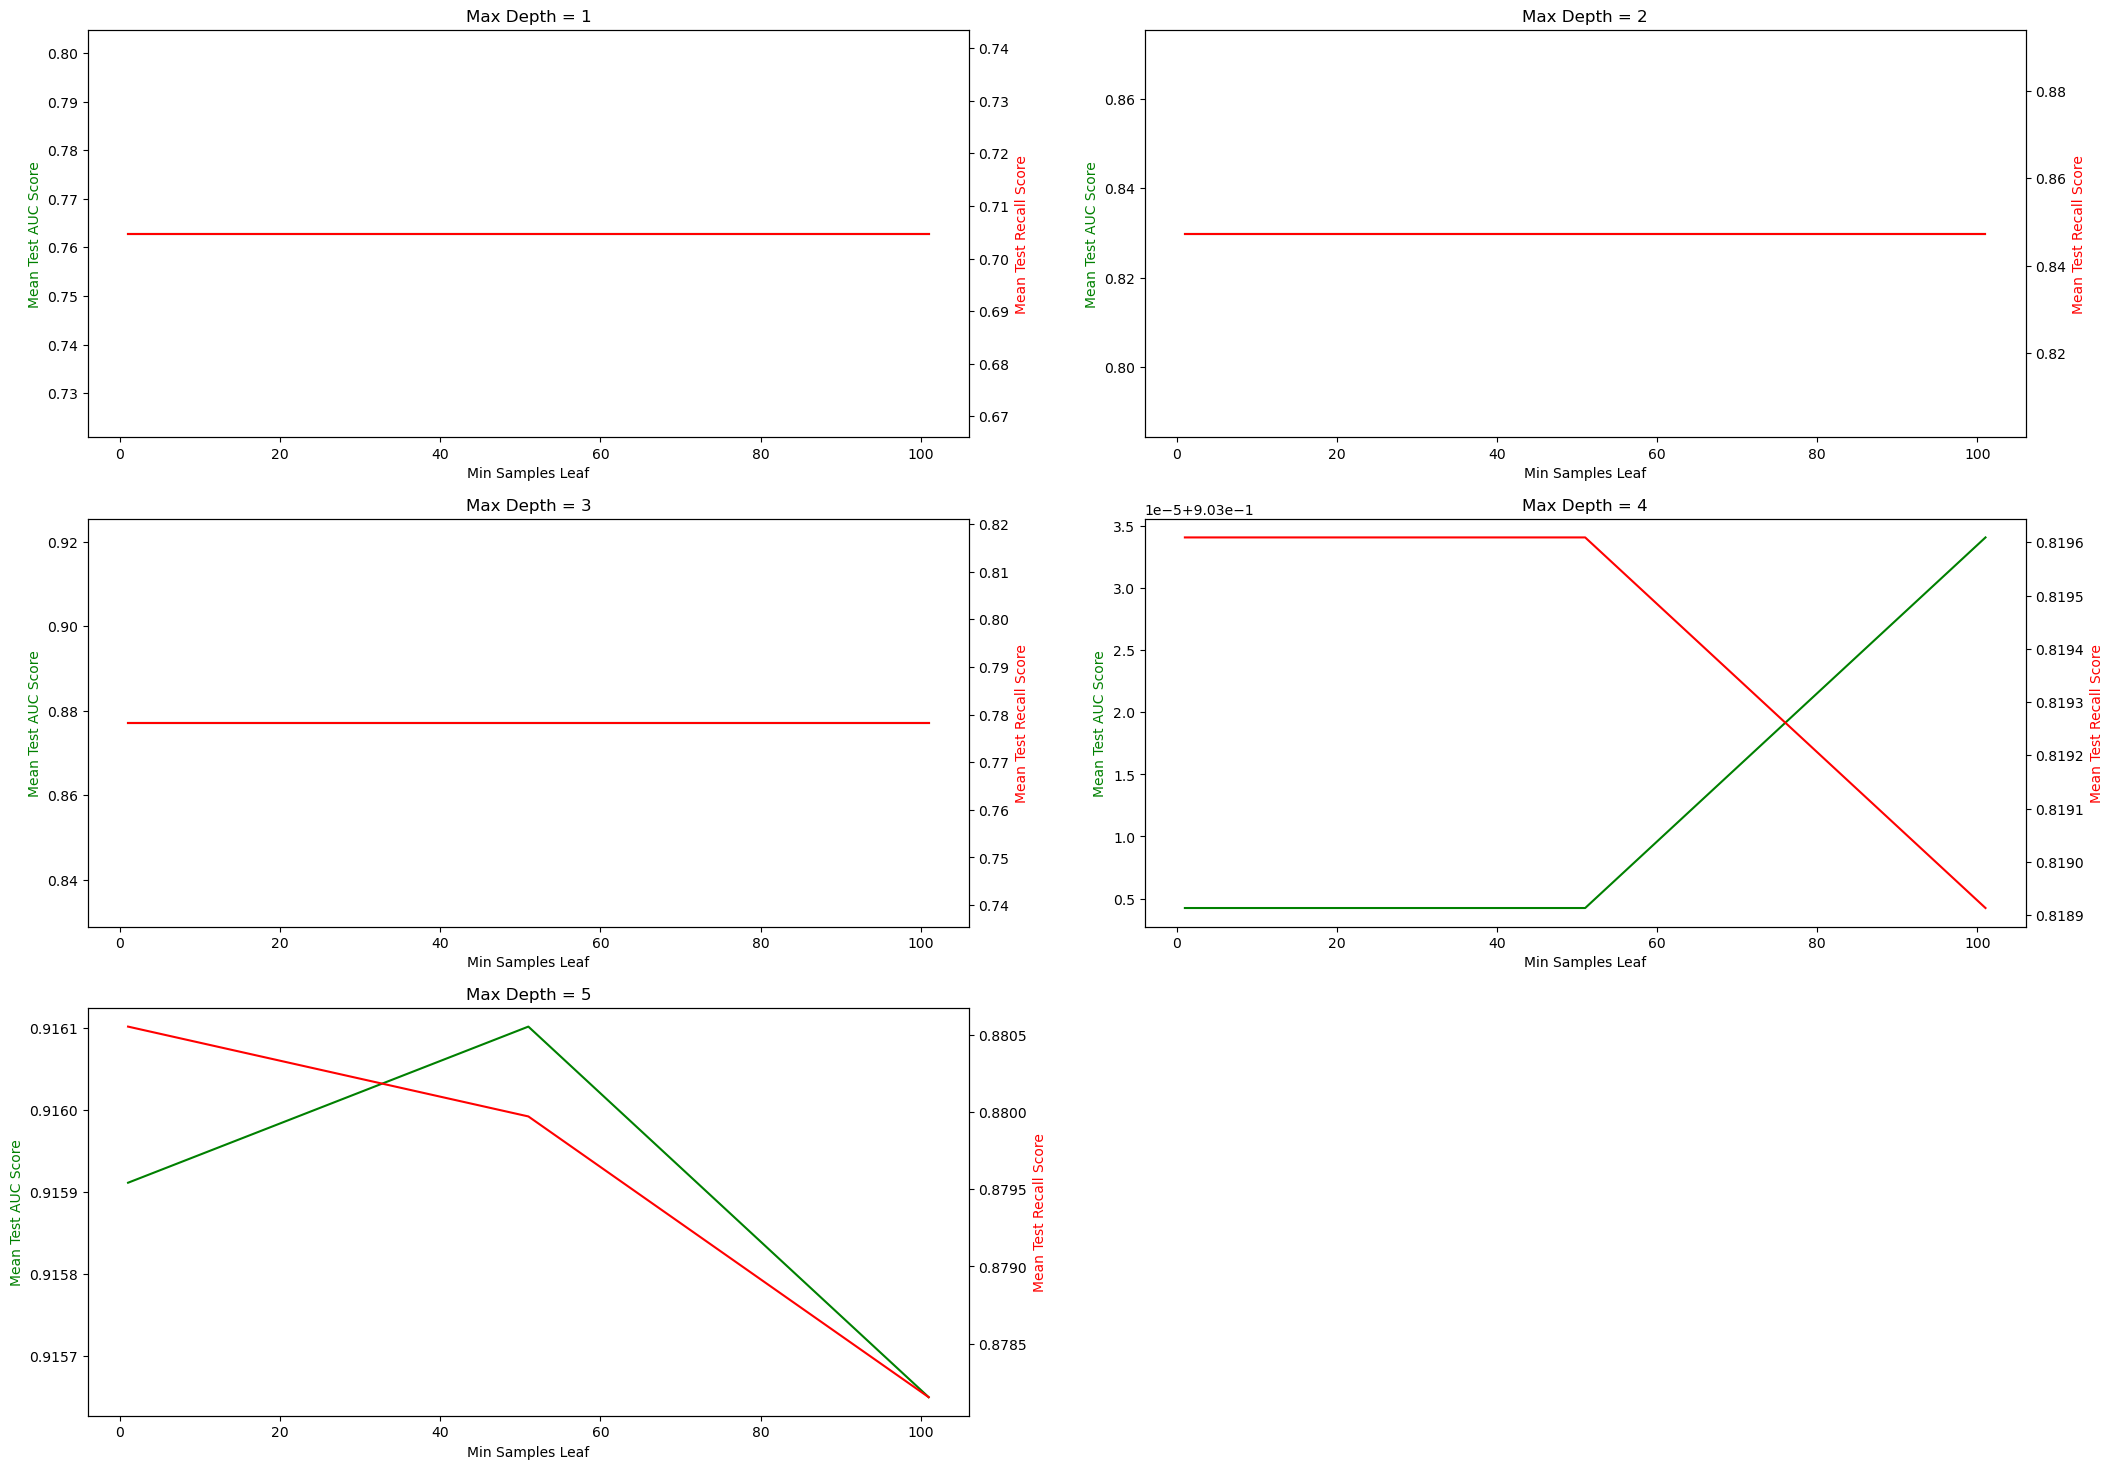

In [105]:
import math
plot_params(decision_tree_cv_results, 'param_decision_tree__max_depth',
                    'param_decision_tree__min_samples_leaf','Max Depth','Min Samples Leaf')

**Interpretations from the plot**


The graph shows the performance of a model with varying “Max Depth” and "Min Samples Leaf" For Max Depth = 1, 2 and 3, the graphs are flat lines, indicating no significant change in performance with different values of the other hyperparameters. However, for Max Depth = 4, there is a noticeable trend and for max depth = 5 the performance improves as the number of features or samples leaf increases up to a certain point before declining.


#### Final Decision Tree Classifer Model

+-----------------------+-------------------------------------------------------+
| Metric                | Value                                                 |
+=======================+=======================================================+
| False Positive Rate   | [0.       0.165648 1.      ]                          |
+-----------------------+-------------------------------------------------------+
| True Positive Rate    | [0.         0.79471545 1.        ]                    |
+-----------------------+-------------------------------------------------------+
| Thresholds            | [2 1 0]                                               |
+-----------------------+-------------------------------------------------------+
| ROC AUC Score         | 0.8145337245751152                                    |
+-----------------------+-------------------------------------------------------+
| Accuracy Score        | 0.8300188867903566                                    |
+---------------

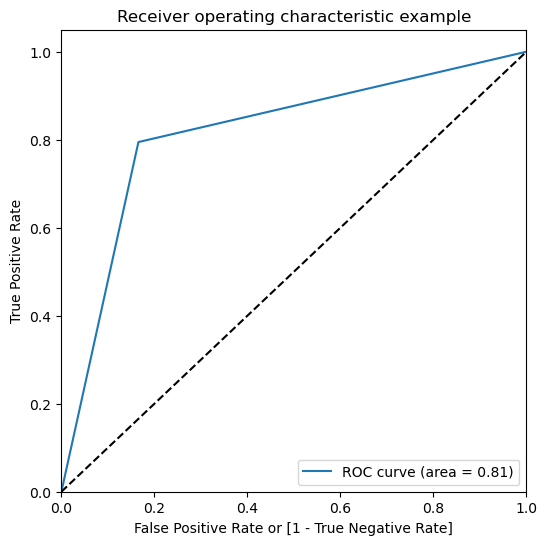

In [106]:
final_decision_tree = DecisionTreeClassifier(random_state = 100, min_samples_leaf = 50, max_depth = 5)
final_decision_tree.fit(X_train_smote, y_train_smote)

y_pred_decision_tree = final_decision_tree.predict(X_test)
summarize_model(y_test, y_pred_decision_tree)

In [120]:
# This is another visualization method
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier, export_text

# Load the iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Fit the classifier with default hyper-parameters
clf = DecisionTreeClassifier(random_state=1234)
model = clf.fit(X, y)

# Export the decision tree to text representation
text_representation = export_text(clf)
print(text_representation)


|--- feature_2 <= 2.45
|   |--- class: 0
|--- feature_2 >  2.45
|   |--- feature_3 <= 1.75
|   |   |--- feature_2 <= 4.95
|   |   |   |--- feature_3 <= 1.65
|   |   |   |   |--- class: 1
|   |   |   |--- feature_3 >  1.65
|   |   |   |   |--- class: 2
|   |   |--- feature_2 >  4.95
|   |   |   |--- feature_3 <= 1.55
|   |   |   |   |--- class: 2
|   |   |   |--- feature_3 >  1.55
|   |   |   |   |--- feature_0 <= 6.95
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- feature_0 >  6.95
|   |   |   |   |   |--- class: 2
|   |--- feature_3 >  1.75
|   |   |--- feature_2 <= 4.85
|   |   |   |--- feature_1 <= 3.10
|   |   |   |   |--- class: 2
|   |   |   |--- feature_1 >  3.10
|   |   |   |   |--- class: 1
|   |   |--- feature_2 >  4.85
|   |   |   |--- class: 2



#### Random Forest Classifer 
Since this is an ensemble of decision trees, we will use SMOTE trainign data without PCA to train. The ensemble will inherently take care of the dimensionality reduction.

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    3.2s finished


+-----------------------+-------------------------------------------------------+
| Metric                | Value                                                 |
+=======================+=======================================================+
| False Positive Rate   | [0.         0.06573531 1.        ]                    |
+-----------------------+-------------------------------------------------------+
| True Positive Rate    | [0.         0.69613821 1.        ]                    |
+-----------------------+-------------------------------------------------------+
| Thresholds            | [2 1 0]                                               |
+-----------------------+-------------------------------------------------------+
| ROC AUC Score         | 0.8152014494605468                                    |
+-----------------------+-------------------------------------------------------+
| Accuracy Score        | 0.9082324186201534                                    |
+---------------

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


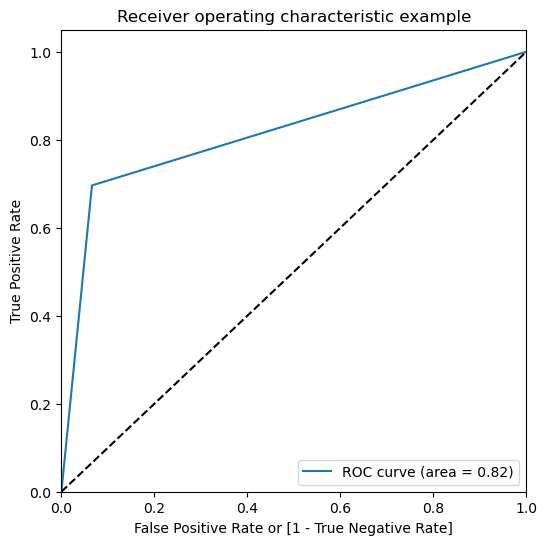

Out of Bag Error : 0.9421946789186879


In [122]:
random_forest_default_model = RandomForestClassifier(random_state = 100, oob_score = True, warm_start = True, 
                                                     verbose = 1, n_jobs= -1)
random_forest_default_model.fit(X_train_smote, y_train_smote)

y_pred_random_forest_default = random_forest_default_model.predict(X_test)
summarize_model(y_test, y_pred_random_forest_default)
print('Out of Bag Error : {}'.format(random_forest_default_model.oob_score_))

**Interpretation**
In this case, the OOB error of 0.942 indicates that the random forest classifier is very inaccurate and makes a lot of mistakes when predicting the class labels of the out-of-bag observations. This could be due to various reasons, such as a small number of trees, a high variance of the trees, or a poor quality of the features.

In [ ]:
#Setting up the pipeline 

random_forest_max_features = range(5, 61, 5)
random_forest_n_estimators = range(50, 251, 50)

random_forest_parameters = {'random_forest__max_features': random_forest_max_features, 
                           'random_forest__n_estimators': random_forest_n_estimators}

random_forest = RandomForestClassifier(random_state = 100, oob_score = True, warm_start = True, n_jobs= 2)

random_forest_pipeline = Pipeline(steps=[('random_forest', random_forest)])

In [ ]:
# create and conduct grid search for hyperparameter tuning

random_forest_grid_search = create_grid_search(random_forest_pipeline, random_forest_parameters, cv_fold_split = 2)
random_forest_cv_results = conduct_grid_search(random_forest_grid_search, X_train_smote, y_train_smote)

In [ ]:
##Validating the hyperparmeter tuning results

plot_params(random_forest_cv_results, 'param_random_forest__n_estimators', 'param_random_forest__max_features', 
            'Number of Estimators', 'Max Features')

#### XGBoost

This is too an ensemble of decision trees and there  I will continue to use SMOTE training data without PCA 



In [ ]:
# Import the XGBClassifier class
from xgboost import XGBClassifier

# Create an XGBClassifier object
xg_boost_default_model = XGBClassifier(random_state=100, verbosity=1, n_jobs=-1)

# Fit the model
xg_boost_default_model.fit(X_train_smote, y_train_smote)

# Predict using the model
y_pred_xg_boost_default = xg_boost_default_model.predict(X_test)

# Summarize the model performance
summarize_model(y_test, y_pred_xg_boost_default)

In [ ]:
# Setting pipeline 
xg_boost_n_estimators = range(50, 501, 50)

xg_boost_parameters = {'xg_boost__n_estimators': xg_boost_n_estimators}

xg_boost = XGBClassifier(random_state = 100,  n_jobs = -1)

xg_boost_pipeline = Pipeline(steps=[('xg_boost', xg_boost)])


In [ ]:
#Hyperparameter tuning 
xg_boost_grid_search = create_grid_search(xg_boost_pipeline, xg_boost_parameters, cv_fold_split = 2)
xg_boost_cv_results = conduct_grid_search(xg_boost_grid_search, X_train_smote, y_train_smote)

In [ ]:
#validate hyperparameters tuning result
plot_hyperparameters(xg_boost_cv_results, 'param_xg_boost__n_estimators', 'Number of Estimators')

#### Final XGBoost Classifier Model


In [ ]:
xg_boost_final_model = XGBClassifier(random_state = 100,  
                                       verbosity = 1, n_jobs = -1, n_estimators = 500)
xg_boost_final_model.fit(X_train_smote, y_train_smote)

y_pred_xg_boost_final = xg_boost_final_model.predict(X_test)
summarize_model(y_test, y_pred_xg_boost_final)

## Identifying important churn indicators and business recommendation

The algorithms were tested with default and SMOTE data, with or without PCA, to compare their performance. They were also hypertuned with other parameters. Only the best results for each algorithm are shown above. The data and PCA options used are:

- SMOTE without PCA for decision trees.
- Normal Training data without PCA for balanced decision trees.
- SMOTE with PCA for logistic regression and SVM.

Decision Tree is the best model for churn prediction based on Recall and AUC Score, even though Random Forest and XgBoost are also good.

In [ ]:
#### Important feature selection
from sklearn.feature_selection import SelectFromModel

sel = SelectFromModel(final_decision_tree)
sel.fit(X_train_smote, y_train_smote)

important_features_results = pd.DataFrame(list(zip(X_train.columns, sel.get_support(), 
                                            final_decision_tree.feature_importances_)))
important_features_results.columns = ('column_name', 'support', 'importance')
important_features_results = important_features_results[important_features_results['support'] == True]
important_features_results.reset_index(inplace = True, drop = True)
important_features_results.drop('support', axis = 1, inplace = True)
important_features_results = important_features_results.sort_values(by='importance', ascending = False)
kpi_results = important_features_results['column_name']
display(important_features_results)

In [ ]:
#analyzing the columns 

plt.figure(figsize = (20, 10))
sns.heatmap(X_train[kpi_results].corr(), annot = True)
plt.show()

In [ ]:
## Analyzing highly correlated KPIs with correlation matrix
kpi_corr_matrix = X_train[kpi_results].corr().abs()

# Select upper triangle of correlation matrix
kpi_upper = kpi_corr_matrix.where(np.triu(np.ones(kpi_corr_matrix.shape), k=1).astype(np.bool))

# Find index of feature columns with correlation greater than 0.5
kpi_corr_columns = [column for column in kpi_upper.columns if any(kpi_upper[column] >= 0.5)]

print('correlated columns : \n {}'.format(kpi_corr_columns))

important_feature_results_without_corr = important_features_results[~important_features_results['column_name']
                                                       .isin(kpi_corr_columns)].copy()

important_features_results_without_corr = important_feature_results_without_corr['column_name']
display(important_feature_results_without_corr)

In [ ]:
# Validating the final important features
plt.figure(figsize = (10, 5))
sns.heatmap(X_train[important_features_results_without_corr].corr(), annot = True)
plt.show()

In [ ]:
#Plot All vs Uncorrelated Importance Features
plt.figure(figsize=(20, 5))

plt.subplot(121)

feature_plot = sns.barplot(x='column_name', y= 'importance', data=important_features_results, 
                           order = important_features_results['column_name'])
feature_plot.set(xlabel = 'KPI', ylabel = 'Importance', title='KPI Importance')

for label in feature_plot.get_xticklabels():
    label.set_rotation(90)

plt.subplot(122)

feature_plot = sns.barplot(x='column_name', y= 'importance', data=important_feature_results_without_corr, 
                           order = important_feature_results_without_corr['column_name'])
feature_plot.set(xlabel = 'KPI', ylabel = 'Importance', title='Non-corelated KPI Importance')

for label in feature_plot.get_xticklabels():
    label.set_rotation(90)
    
plt.show()

In [ ]:
fig, axes = plt.subplots(nrows=9, ncols=1, figsize = (30,15))

plt.suptitle('Features - Non-Churn vs Churn')

total_ic_mou_df = telecom_hvc.groupby(['churn'])['total_ic_mou_7', 'total_ic_mou_8'].mean()
total_ic_mou_ax = total_ic_mou_df.plot.bar(ax=axes[0,0], title = 'Total Incoming Minutes of Usage', rot = 0)
total_ic_mou_ax.legend(loc='upper right')

roam_og_mou_df = telecom_hvc.groupby(['churn'])['roam_og_mou_6', 'roam_og_mou_7', 'roam_og_mou_8'].mean()
roam_og_mou_ax = roam_og_mou_df.plot.bar(ax=axes[0,1], title = 'Roaming Outgoing Minutes of Usage', rot = 0)
roam_og_mou_ax.legend(loc='upper left')

day_of_last_rech_df = telecom_hvc.groupby(['churn'])['day_of_last_rech_6', 'day_of_last_rech_7', 'day_of_last_rech_8'].median()
day_of_last_rech_ax = day_of_last_rech_df.plot.bar(ax=axes[0, 2], title = 'Day of Last Recharge', rot = 0)
day_of_last_rech_ax.legend(bbox_to_anchor=(0.7, 1))

last_day_rch_amt_df = telecom_hvc.groupby(['churn'])['last_day_rch_amt_6', 'last_day_rch_amt_7', 'last_day_rch_amt_8'].mean()
last_day_rch_amt_ax = last_day_rch_amt_df.plot.bar(ax=axes[1, 0], title = 'Last Day Recharge Amount')
last_day_rch_amt_ax.legend(loc='upper right')

arpu_df = telecom_hvc.groupby(['churn'])['arpu_6', 'arpu_7', 'arpu_8'].mean()
arpu_df_ax = arpu_df.plot.bar(ax=axes[1, 1], title = 'Average revenue per user', rot = 0)
arpu_df_ax.legend(loc='upper right')

vbc_3g_df = telecom_hvc.groupby(['churn'])['vbc_3g_6', 'vbc_3g_7', 'vbc_3g_8'].mean()
vbc_3g_df_ax = vbc_3g_df.plot.bar(ax=axes[1, 2], title = 'VBC 3g Data Usage', rot = 0)
vbc_3g_df_ax.legend(loc='upper right')

total_rech_num_df = telecom_hvc.groupby(['churn'])['total_rech_num_6', 'total_rech_num_7', 'total_rech_num_8'].mean()
total_rech_num_df_ax = total_rech_num_df.plot.bar(ax=axes[2, 0], title = 'Total number of recharge', rot = 0)
total_rech_num_df_ax.legend(loc='upper right')


plt.show()

### Business Recommendations

1. **Roaming Outgoing Calls and Revenue**:
   - Churn customers exhibit higher usage of roaming outgoing calls, resulting in greater average revenue per user compared to non-churn customers.
   - This suggests that churn customers are likely part of a customer base that frequently travels between different circles.

2. **Age on Network and Frequent Switching**:
   - Churn customers have a shorter "age on network" compared to non-churn customers.
   - Frequent switching of telco operators for cost-saving purposes contributes to this trend.
   - Additionally, churn customers recharge with smaller amounts but more frequently, indicating a need-based approach.

3. **Incoming Calls and Local Usage**:
   - Non-churn customers use more incoming calls and 3G volume.
   - This behavior suggests that non-churn customers operate primarily within the same circle.

4. **Importance of the "Bad Phase"**:
   - The "bad phase" plays a crucial role in churn prediction, as many significant variables originate from this period.

5. **Voice Usage in the "Action Phase"**:
   - Voice usage (incoming calls) during the "action phase" emerges as a key feature for churn prediction.
   - Companies should closely monitor voice usage and consider offering incentives or special offers to potential churners identified by the model.

6. **ARPU Changes as Warning Signs**:
   - Significant changes (especially decreases) in average revenue per user (ARPU) should be treated as warning signs of potential churn.
   - Prompt action is necessary for users showing substantial ARPU fluctuations.

7. **Last Day Recharge Amount**:
   - The recharge amount on the last day of the action month serves as a critical indicator for predicting churn.
   - Companies can use this information to assess whether a customer is likely to churn.

8. **Focus on Recharge Amount and Usage**:
   - Recharge amount and minutes of usage should be focal points for identifying potential churn.
   - Monitoring these metrics can help proactively address churn risks.
